# 📊 Statistics & Probability — Making Decisions Under Uncertainty

> **What you'll learn:** how to summarize data honestly, reason with probabilities and Bayes' theorem, understand the Central Limit Theorem, build confidence intervals (including the bootstrap), run hypothesis tests *correctly*, plan sample sizes with power analysis, avoid the multiple-testing and peeking traps, and run a complete A/B test on a real 64,000-customer experiment.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🔴 Advanced (A/B testing, multiple testing) |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [NumPy](01_NumPy.ipynb) (arrays, vectorization) · [Pandas](02_Pandas.ipynb) (DataFrames, groupby) |
| **Tested with** | Python 3.12 · numpy 2.5 · pandas 3.0 · scipy 1.18 · statsmodels 0.15 · matplotlib 3.11 · scikit-learn 1.9 |
| **Interview relevance** | ⭐⭐⭐ Very high — "what is a p-value?", "how many users do we need?", Bayes' medical-test puzzle, "you tested 20 metrics…", correlation vs causation, and A/B test design come up in almost every ML/data interview loop |

## 🤔 What Is Statistics & Probability?

Imagine you are cooking a big pot of soup and want to know if it is salty enough. You don't drink the whole pot — you **stir it and taste one spoonful**.

- **Probability** goes *forward*: "if the soup has this much salt, what will a spoonful taste like?" (known cause → predict data)
- **Statistics** goes *backward*: "this spoonful tastes like this — what does the whole pot taste like, and how sure am I?" (observed data → infer cause)

Stirring is **random sampling**, a bigger spoon is a **bigger sample**, and "how sure am I?" is what confidence intervals and p-values measure. You can never be 100% certain from a spoonful — statistics tells you *how uncertain* you are.

| Term | Plain-English meaning | Soup example |
|---|---|---|
| **Population** | everything you care about | the whole pot |
| **Sample** | the part you actually observe | one spoonful |
| **Parameter** | a true (usually unknown) number about the population | true saltiness of the pot |
| **Statistic** | a number computed from the sample | saltiness of the spoonful |
| **Random variable** | a quantity whose value depends on chance | saltiness of a random spoonful |
| **Distribution** | which values a random variable takes, and how often | how saltiness varies spoon to spoon |

We use **`scipy.stats`** (distributions and tests) and **`statsmodels`** (power analysis, proportions, multiple testing). *The optimization and linear-algebra parts of SciPy live in [Math for ML](04_Math_for_ML.ipynb).*

## 🎯 Why It Matters

- **Shipping models is an experiment.** A new recommender or ranking model goes live through an **A/B test**; you must decide whether the lift is real, how many users you need, and when to stop.
- **Every metric has error bars.** "Model B has 0.4% higher accuracy" means nothing without a confidence interval — the bootstrap gives you one for any metric.
- **ML is built on it.** Loss functions are negative log-likelihoods (MSE ↔ Gaussian, cross-entropy ↔ Bernoulli), Naive Bayes is Bayes' theorem, drift monitoring uses statistical tests, and precision at low prevalence is the base-rate fallacy in disguise.
- **In interviews** you will be asked to *explain* a p-value without the usual mistakes, compute a **sample size**, solve a **Bayes** puzzle, spot **peeking** or **Simpson's paradox**, and **design** an A/B test end to end. This notebook practises all of them with real data.

## ✅ By the End You Can

- [ ] Summarize data with the right center and spread, and explain why the median and MAD resist outliers
- [ ] Apply Bayes' theorem and explain the base-rate fallacy with natural frequencies
- [ ] Explain the Central Limit Theorem and build t-based and bootstrap confidence intervals
- [ ] Choose and run the right test (t-tests, chi-square, Mann–Whitney) and interpret p-values **correctly**
- [ ] Compute statistical power and sample size, and correct for multiple testing
- [ ] Plan, run, and analyze an A/B test — including sanity checks, practical significance, and the peeking problem

## 📋 Table of Contents

1. [Descriptive Statistics: Center, Spread, Shape](#1.-Descriptive-Statistics:-Center,-Spread,-Shape-🟢)
2. [Robust Statistics: Taming Outliers](#2.-Robust-Statistics:-Taming-Outliers-🟢)
3. [Probability Rules and Bayes' Theorem](#3.-Probability-Rules-and-Bayes'-Theorem-🟢)
4. [Key Probability Distributions](#4.-Key-Probability-Distributions-🟢)
5. [Sampling and the Central Limit Theorem](#5.-Sampling-and-the-Central-Limit-Theorem-🟡)
6. [Confidence Intervals: t-Based and Bootstrap](#6.-Confidence-Intervals:-t-Based-and-Bootstrap-🟡)
7. [Hypothesis Testing Done Right](#7.-Hypothesis-Testing-Done-Right-🟡)
8. [Power and Sample Size](#8.-Power-and-Sample-Size-🟡)
9. [t-Tests: One-Sample, Paired, and Welch](#9.-t-Tests:-One-Sample,-Paired,-and-Welch-🟡)
10. [Chi-Square and Non-Parametric Tests](#10.-Chi-Square-and-Non-Parametric-Tests-🟡)
11. [Correlation, Causation, and Simpson's Paradox](#11.-Correlation,-Causation,-and-Simpson's-Paradox-🟡)
12. [Multiple Testing: Bonferroni and Benjamini–Hochberg](#12.-Multiple-Testing:-Bonferroni-and-Benjamini–Hochberg-🔴)
13. [Maximum Likelihood Estimation](#13.-Maximum-Likelihood-Estimation-🔴)
14. [A/B Testing: The Complete Workflow](#14.-A/B-Testing:-The-Complete-Workflow-🔴)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Did-the-E-Mail-Campaign-Work?) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

- Real datasets are downloaded once (a few MB in total) and cached in `_outputs/`.
- The `check()` helper gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint). Numbers are compared with a small relative tolerance.

In [1]:
# %pip install -q "numpy>=2.0" "pandas>=2.2" "scipy>=1.14" "statsmodels>=0.14" "matplotlib>=3.9" "seaborn>=0.13" "scikit-learn>=1.5"

import sys
import urllib.request
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns                     # used here only to download real example datasets
import statsmodels
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import NormalIndPower, TTestIndPower
from statsmodels.stats.proportion import confint_proportions_2indep, proportion_effectsize, proportions_ztest

print(f"Python {sys.version.split()[0]} | NumPy {np.__version__} | pandas {pd.__version__} | SciPy {scipy.__version__} "
      f"| statsmodels {statsmodels.__version__} | Matplotlib {matplotlib.__version__}")

rng = np.random.default_rng(42)            # one seeded generator → the whole notebook is reproducible
np.set_printoptions(precision=4, suppress=True)
OUTPUT_DIR = Path("_outputs")              # downloads and files we write go here (ignored by git)
OUTPUT_DIR.mkdir(exist_ok=True)
ALPHA = 0.05                               # significance level used throughout


def load_csv(url, filename):
    """Download a CSV once into _outputs/, then read the local copy."""
    path = OUTPUT_DIR / filename
    if not path.exists():
        print(f"downloading {url} …")
        urllib.request.urlretrieve(url, path)
    return pd.read_csv(path)


def check(name, got, expected, hint="", rtol=1e-3):
    """✅ if correct (numbers within rtol), ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    got_arr, exp_arr = np.asarray(got), np.asarray(expected)
    if got_arr.shape != exp_arr.shape:
        raise AssertionError(f"❌ {name}: shape {got_arr.shape}, expected {exp_arr.shape}. {hint}")
    numeric = np.issubdtype(exp_arr.dtype, np.number) and exp_arr.dtype != bool
    ok = np.allclose(got_arr.astype(float), exp_arr, rtol=rtol, atol=1e-9) if numeric else np.array_equal(got_arr, exp_arr)
    assert ok, f"❌ {name}: not quite (got {got}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | NumPy 2.5.3 | pandas 3.0.5 | SciPy 1.18.1 | statsmodels 0.15.0 | Matplotlib 3.11.2


## 1. Descriptive Statistics: Center, Spread, Shape 🟢

Before any test, *describe* your data. Three questions:

| Question | Statistics | One-line meaning |
|---|---|---|
| Where is the **center**? | mean, median, mode | balance point · middle value · most common value |
| How **spread out** is it? | variance, standard deviation, range, IQR | typical distance from the mean · max − min · width of the middle 50% |
| What **shape** is it? | skewness, a histogram | is one tail longer than the other? |

**Sample variance divides by n − 1**, not n (called *Bessel's correction*, `ddof=1`): a sample is on average closer to its own mean than to the true mean, so dividing by n would underestimate the spread. ⚠️ **pandas uses `ddof=1` by default, NumPy uses `ddof=0`.**

We use a real dataset: **244 restaurant bills** one waiter recorded (the classic `tips` dataset).

In [2]:
tips = sns.load_dataset("tips")
tips["tip_pct"] = tips["tip"] / tips["total_bill"]
bills = tips["total_bill"]

print(f"n = {len(bills)} bills")
print(f"mean   = ${bills.mean():.2f}   (balance point)")
print(f"median = ${bills.median():.2f}   (middle value)")
print(f"mode (rounded to $1) = ${bills.round().mode().iloc[0]:.0f}")
print(f"variance (ddof=1) = {bills.var():.2f} $²  |  std = ${bills.std():.2f}")
print(f"NumPy std (ddof=0) = ${np.std(bills.to_numpy()):.2f}  ← slightly smaller")
q1, q3 = bills.quantile([0.25, 0.75])
print(f"range = ${bills.max() - bills.min():.2f}  |  IQR = Q3 − Q1 = {q3:.2f} − {q1:.2f} = ${q3 - q1:.2f}")
skew = stats.skew(bills)
print(f"skewness = {skew:.2f} → {'long right tail, so mean > median' if skew > 0 else 'long left tail or symmetric'}")

n = 244 bills
mean   = $19.79   (balance point)
median = $17.80   (middle value)
mode (rounded to $1) = $16
variance (ddof=1) = 79.25 $²  |  std = $8.90
NumPy std (ddof=0) = $8.88  ← slightly smaller
range = $47.74  |  IQR = Q3 − Q1 = 24.13 − 13.35 = $10.78
skewness = 1.13 → long right tail, so mean > median


In [3]:
tips[["total_bill", "tip", "tip_pct"]].describe().round(3)

,total_bill,tip,tip_pct
count,244.000,244.000,244.000
mean,19.786,2.998,0.161
std,8.902,1.384,0.061
min,3.070,1.000,0.036
25%,13.348,2.000,0.129
50%,17.795,2.900,0.155
75%,24.127,3.562,0.191
max,50.810,10.000,0.710


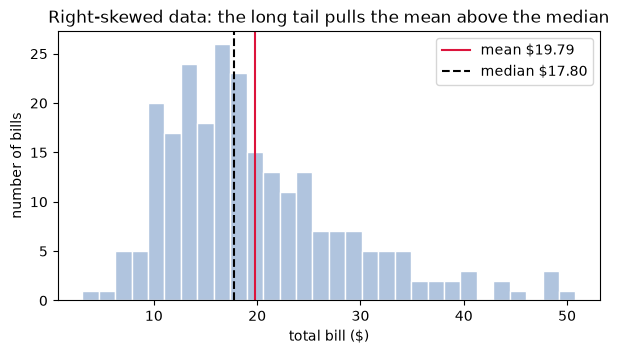

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(bills, bins=30, color="lightsteelblue", edgecolor="white")
ax.axvline(bills.mean(), color="crimson", label=f"mean ${bills.mean():.2f}")
ax.axvline(bills.median(), color="black", linestyle="--", label=f"median ${bills.median():.2f}")
ax.set(xlabel="total bill ($)", ylabel="number of bills", title="Right-skewed data: the long tail pulls the mean above the median")
ax.legend()
plt.show()

### ✍️ Your Turn

Compute the **interquartile range (IQR)** of the `tip` column (Q3 − Q1). Store a float in `tip_iqr`.

In [5]:
tip_iqr = None  # TODO: your code here
check("tip_iqr", tip_iqr, 1.5625, hint="tips['tip'].quantile(0.75) - tips['tip'].quantile(0.25), or stats.iqr(tips['tip']).")

⏳ tip_iqr: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
tip_iqr = tips["tip"].quantile(0.75) - tips["tip"].quantile(0.25)
check("tip_iqr", tip_iqr, 1.5625)
check("tip_iqr (scipy)", stats.iqr(tips["tip"]), 1.5625)
```
</details>

> 💡 **Interview angle:** "Mean or median for house prices or API latency?" — for skewed data report the **median and high percentiles** (p50 / p95 / p99); the mean is right when you need a total (e.g. total cost = mean × count).

## 2. Robust Statistics: Taming Outliers 🟢

One typo can wreck a mean. A statistic is **robust** if a few crazy values barely move it.

- **Median** instead of mean
- **MAD** (median absolute deviation: the median distance from the median) instead of standard deviation. Multiplied by 1.4826 (`scale="normal"`) it matches the std for normal data.
- **Trimmed mean**: drop the top and bottom 10%, then average.

*Controlled example:* we add **one** mistyped bill ($50.79 entered as $5079) to the real data.

In [6]:
clean = tips["total_bill"].to_numpy()
dirty = np.append(clean, 5079.0)          # one bad row out of 245


def summarize(x):
    return {
        "mean": x.mean(),
        "std": x.std(ddof=1),
        "median": np.median(x),
        "10% trimmed mean": stats.trim_mean(x, 0.1),
        "MAD (normal scale)": stats.median_abs_deviation(x, scale="normal"),
        "IQR": stats.iqr(x),
    }


robust_table = pd.DataFrame({"clean": summarize(clean), "with one typo": summarize(dirty)})
robust_table["change %"] = 100 * (robust_table["with one typo"] / robust_table["clean"] - 1)
robust_table.round(2)

,clean,with one typo,change %
mean,19.79,40.44,104.37
std,8.90,323.34,3532.09
median,17.80,17.81,0.08
10% trimmed mean,18.73,18.80,0.38
MAD (normal scale),7.46,7.49,0.40
IQR,10.78,10.90,1.11


**Outlier detection.** The classic rule "|z| > 3" uses the mean and std — which the outlier itself inflates. In a sample of size n, a z-score can never exceed $(n-1)/\sqrt{n}$, so in **small samples the classic rule can never fire**. A **robust z-score** uses the median and MAD instead.

In [7]:
small = np.append(clean[:9], 5079.0)       # 9 real bills + the typo
z_classic = (small - small.mean()) / small.std(ddof=1)
z_robust = (small - np.median(small)) / stats.median_abs_deviation(small, scale="normal")

print(f"max possible |z| with n={len(small)}: {(len(small) - 1) / np.sqrt(len(small)):.2f}")
print(f"classic z of the typo: {z_classic[-1]:.2f} → flagged (|z| > 3)? {abs(z_classic[-1]) > 3}")
print(f"robust  z of the typo: {z_robust[-1]:.1f} → flagged (|z| > 3.5)? {abs(z_robust[-1]) > 3.5}")

iqr_low, iqr_high = np.percentile(clean, 25) - 1.5 * stats.iqr(clean), np.percentile(clean, 75) + 1.5 * stats.iqr(clean)
print(f"\nTukey's 1.5×IQR fences on the real bills: [{iqr_low:.2f}, {iqr_high:.2f}] → {((clean < iqr_low) | (clean > iqr_high)).sum()} bills outside")

max possible |z| with n=10: 2.85
classic z of the typo: 2.85 → flagged (|z| > 3)? False
robust  z of the typo: 689.7 → flagged (|z| > 3.5)? True

Tukey's 1.5×IQR fences on the real bills: [-2.82, 40.30] → 9 bills outside


Values outside the fences are **candidates to investigate**, not automatically errors — a $48 bill for a party of six is real data.

> 💡 **Interview angle:** "How do you handle outliers?" — first ask *why* they exist (bug vs. rare but real). Detect with IQR fences or robust z-scores (median/MAD), then fix errors, cap/winsorize, use robust statistics or losses (Huber), or model heavy tails. Never delete silently.

## 3. Probability Rules and Bayes' Theorem 🟢

A **probability** is a number from 0 (impossible) to 1 (certain). Four rules cover most interview questions:

| Rule | Formula | Example with two dice |
|---|---|---|
| Complement | $P(\text{not }A) = 1 - P(A)$ | P(no six on one die) = 5/6 |
| Addition | $P(A \text{ or } B) = P(A) + P(B) - P(A \text{ and } B)$ | P(sum is 7 **or** a double) |
| Conditional | $P(A \mid B) = P(A \text{ and } B) / P(B)$ | P(sum is 12 **given** the first die is 6) |
| Independence | $A, B$ independent if $P(A \mid B) = P(A)$ | two separate dice |

Let's verify with a million simulated rolls.

In [8]:
rolls = rng.integers(1, 7, size=(1_000_000, 2))
total = rolls.sum(axis=1)
first_is_six = rolls[:, 0] == 6
double = rolls[:, 0] == rolls[:, 1]

print(f"P(sum = 7)                  ≈ {(total == 7).mean():.4f}   (exact 1/6 = {1 / 6:.4f})")
print(f"P(sum = 7 | first die = 6)  ≈ {(total[first_is_six] == 7).mean():.4f}   → same as P(sum = 7): independent")
print(f"P(sum = 12)                 ≈ {(total == 12).mean():.4f}   (exact 1/36 = {1 / 36:.4f})")
print(f"P(sum = 12 | first die = 6) ≈ {(total[first_is_six] == 12).mean():.4f}   → changed: NOT independent")
print(f"P(sum = 7 or double)        ≈ {((total == 7) | double).mean():.4f}   (1/6 + 1/6 − 0 = {1 / 3:.4f})")

P(sum = 7)                  ≈ 0.1667   (exact 1/6 = 0.1667)
P(sum = 7 | first die = 6)  ≈ 0.1659   → same as P(sum = 7): independent
P(sum = 12)                 ≈ 0.0278   (exact 1/36 = 0.0278)
P(sum = 12 | first die = 6) ≈ 0.1671   → changed: NOT independent
P(sum = 7 or double)        ≈ 0.3333   (1/6 + 1/6 − 0 = 0.3333)


### Bayes' theorem — updating beliefs with evidence

$$P(\text{disease} \mid +) = \frac{P(+ \mid \text{disease})\,P(\text{disease})}{P(+ \mid \text{disease})\,P(\text{disease}) + P(+ \mid \text{healthy})\,P(\text{healthy})}$$

- **Prior** $P(\text{disease})$ — how common the disease is before testing (prevalence)
- **Sensitivity** $P(+ \mid \text{disease})$ — the test catches sick people
- **Specificity** $P(- \mid \text{healthy})$ — the test clears healthy people; $1 - $ specificity is the false-positive rate
- **Posterior** $P(\text{disease} \mid +)$ — what we actually want

**Puzzle:** a disease affects **1%** of people. The test has **90% sensitivity** and **91% specificity**. You test positive. What's the chance you're sick? Most people (and many doctors) guess ~90%.

**Natural frequencies** make it obvious. Picture 100,000 people:

```
100,000 people ─┬─   1,000 sick    ─┬─  900 test +   ← true positives
                │                   └─  100 test −
                └─  99,000 healthy ─┬─ 8,910 test +  ← false positives (9% of 99,000)
                                    └─ 90,090 test −
P(sick | +) = 900 / (900 + 8,910) ≈ 9%
```

In [9]:
def posterior(prior, sensitivity, specificity):
    """P(condition | positive test) via Bayes' theorem."""
    true_pos = sensitivity * prior
    false_pos = (1 - specificity) * (1 - prior)
    return true_pos / (true_pos + false_pos)


print(f"Bayes formula : P(sick | +) = {posterior(0.01, 0.90, 0.91):.2%}")

# Check by simulating a population of 1,000,000 people
n_people = 1_000_000
sick = rng.random(n_people) < 0.01
positive = np.where(sick, rng.random(n_people) < 0.90, rng.random(n_people) < 0.09)
print(f"Simulation    : P(sick | +) ≈ {sick[positive].mean():.2%}  ({positive.sum():,} positives, {sick[positive].sum():,} truly sick)")

Bayes formula : P(sick | +) = 9.17%


Simulation    : P(sick | +) ≈ 9.04%  (98,336 positives, 8,891 truly sick)


The **base rate** (1%) dominates: false positives from the huge healthy group swamp the true positives. This is exactly why a fraud model with 99% accuracy can still have terrible **precision** — precision *is* $P(\text{fraud} \mid \text{flagged})$.

### ✍️ Your Turn

The same test is used in a clinic where **10%** of patients have the disease. Compute `p_sick_clinic` = P(sick | positive).

In [10]:
p_sick_clinic = None  # TODO: your code here
check("p_sick_clinic", p_sick_clinic, 0.5263158, hint="Call posterior(prior, sensitivity, specificity) with prior=0.10.")

⏳ p_sick_clinic: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
p_sick_clinic = posterior(0.10, 0.90, 0.91)
check("p_sick_clinic", p_sick_clinic, 0.5263158)
```

Same test, very different meaning: 0.09 / (0.09 + 0.081) ≈ 53%. The prior matters as much as the test.
</details>

> 💡 **Interview angle:** Always answer Bayes puzzles with **natural frequencies** ("out of 100,000 people…") — it's fast, hard to get wrong, and shows the base-rate intuition interviewers are looking for. Then connect it to precision/recall at low prevalence.

## 4. Key Probability Distributions 🟢

A **distribution** describes how likely each value is. *Discrete* distributions (counts) have a **PMF** (probability of each exact value); *continuous* ones (measurements) have a **PDF** (density — area under the curve is probability).

| Distribution | Models | Parameters | ML/product example |
|---|---|---|---|
| **Bernoulli** | one yes/no trial | p | did this visitor click? |
| **Binomial** | number of successes in n trials | n, p | clicks out of 500 visitors |
| **Poisson** | count of events in a fixed interval | λ (rate = mean = variance) | support tickets per hour |
| **Normal** | sums of many small effects | μ, σ | measurement error, heights |
| **Exponential** | waiting time between Poisson events | scale = 1/λ | minutes until the next ticket |

Every `scipy.stats` distribution has the same methods: `pmf`/`pdf`, `cdf` (P(X ≤ x)), `sf` = 1 − cdf (P(X > x)), `ppf` (inverse cdf → percentiles), `mean`, `std`, and `rvs` (random samples).

In [11]:
visitor = stats.bernoulli(p=0.10)             # one visitor clicks with probability 10%
clicks = stats.binom(n=500, p=0.10)           # clicks out of 500 visitors
tickets = stats.poisson(mu=4)                 # 4 tickets per hour on average
height = stats.norm(loc=170, scale=10)        # heights in cm (roughly)
wait = stats.expon(scale=15)                  # mean 15 minutes between tickets

print(f"Bernoulli: P(click) = {visitor.pmf(1):.2f} | mean = {visitor.mean():.2f} | variance = p(1−p) = {visitor.var():.3f}")
print(f"Binomial : P(exactly 50 clicks) = {clicks.pmf(50):.4f} | P(≥ 60 clicks) = sf(59) = {clicks.sf(59):.4f}")
print(f"Poisson  : P(0 tickets) = {tickets.pmf(0):.4f} | P(≥ 8 tickets) = {tickets.sf(7):.4f} | mean = var = {tickets.var():.0f}")
print(f"Normal   : P(height < 150) = {height.cdf(150):.4f} | 95th percentile = {height.ppf(0.95):.1f} cm")
print(f"Expon.   : P(wait > 30 min) = {wait.sf(30):.4f} | P(wait > 45 | already waited 15) = {wait.sf(45) / wait.sf(15):.4f}  ← memoryless")

for k in (1, 2, 3):
    print(f"Normal: P(within {k} std of mean) = {stats.norm.cdf(k) - stats.norm.cdf(-k):.4f}")

Bernoulli: P(click) = 0.10 | mean = 0.10 | variance = p(1−p) = 0.090
Binomial : P(exactly 50 clicks) = 0.0594 | P(≥ 60 clicks) = sf(59) = 0.0810
Poisson  : P(0 tickets) = 0.0183 | P(≥ 8 tickets) = 0.0511 | mean = var = 4
Normal   : P(height < 150) = 0.0228 | 95th percentile = 186.4 cm
Expon.   : P(wait > 30 min) = 0.1353 | P(wait > 45 | already waited 15) = 0.1353  ← memoryless
Normal: P(within 1 std of mean) = 0.6827
Normal: P(within 2 std of mean) = 0.9545
Normal: P(within 3 std of mean) = 0.9973


⚠️ For **discrete** distributions, "at least 60" is `sf(59)`, because `sf(x)` means *strictly greater than* x.

Now let's check that simulated samples match the theory — and see a famous shortcut: a Binomial with many trials and a tiny p is almost exactly a Poisson.

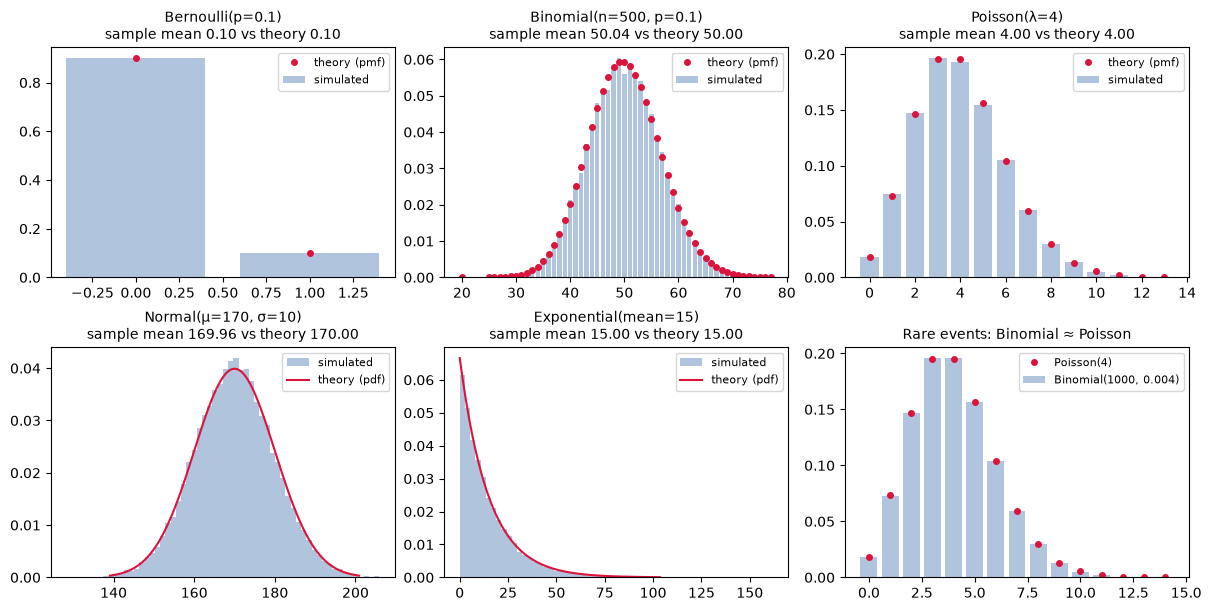

largest probability gap between Binomial(1000, 0.004) and Poisson(4): 0.0004


In [12]:
n_sim = 20_000
fig, axes = plt.subplots(2, 3, figsize=(12, 6), layout="constrained")


def compare_discrete(ax, dist, title):
    samples = dist.rvs(size=n_sim, random_state=rng)
    values, counts = np.unique(samples, return_counts=True)
    ax.bar(values, counts / n_sim, color="lightsteelblue", label="simulated")
    ax.plot(values, dist.pmf(values), "o", color="crimson", ms=4, label="theory (pmf)")
    ax.set_title(f"{title}\nsample mean {samples.mean():.2f} vs theory {dist.mean():.2f}", fontsize=10)
    ax.legend(fontsize=8)


def compare_continuous(ax, dist, title):
    samples = dist.rvs(size=n_sim, random_state=rng)
    ax.hist(samples, bins=60, density=True, color="lightsteelblue", label="simulated")
    grid = np.linspace(*dist.ppf([0.001, 0.999]), 200)
    ax.plot(grid, dist.pdf(grid), color="crimson", label="theory (pdf)")
    ax.set_title(f"{title}\nsample mean {samples.mean():.2f} vs theory {dist.mean():.2f}", fontsize=10)
    ax.legend(fontsize=8)


compare_discrete(axes[0, 0], visitor, "Bernoulli(p=0.1)")
compare_discrete(axes[0, 1], clicks, "Binomial(n=500, p=0.1)")
compare_discrete(axes[0, 2], tickets, "Poisson(λ=4)")
compare_continuous(axes[1, 0], height, "Normal(μ=170, σ=10)")
compare_continuous(axes[1, 1], wait, "Exponential(mean=15)")

k = np.arange(0, 15)
axes[1, 2].bar(k, stats.binom(n=1000, p=0.004).pmf(k), color="lightsteelblue", label="Binomial(1000, 0.004)")
axes[1, 2].plot(k, stats.poisson(mu=4).pmf(k), "o", color="crimson", ms=4, label="Poisson(4)")
axes[1, 2].set_title("Rare events: Binomial ≈ Poisson", fontsize=10)
axes[1, 2].legend(fontsize=8)
plt.show()

max_gap = np.abs(stats.binom(n=1000, p=0.004).pmf(k) - stats.poisson(mu=4).pmf(k)).max()
print(f"largest probability gap between Binomial(1000, 0.004) and Poisson(4): {max_gap:.4f}")

### ✍️ Your Turn

Support tickets arrive at λ = 4 per hour. What is the probability of **at least 2** tickets in an hour? Store it in `p_at_least_2`.

In [13]:
p_at_least_2 = None  # TODO: your code here
check("p_at_least_2", p_at_least_2, 0.9084218, hint="'At least 2' = P(X > 1) = stats.poisson(4).sf(1).")

⏳ p_at_least_2: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
p_at_least_2 = stats.poisson(mu=4).sf(1)          # P(X > 1) = P(X ≥ 2)
check("p_at_least_2", p_at_least_2, 0.9084218)
check("p_at_least_2 (complement)", 1 - stats.poisson(mu=4).cdf(1), 0.9084218)
```
</details>

> 💡 **Interview angle:** "Which distribution would you use for X?" — counts per interval → **Poisson** (check mean ≈ variance; if variance is much bigger, the data are *overdispersed* → negative binomial); successes out of n → **Binomial**; time between events → **Exponential**; averages of many things → **Normal** (by the CLT, next).

## 5. Sampling and the Central Limit Theorem 🟡

The **Central Limit Theorem (CLT)** is the reason most statistical tests work:

> If you take many independent samples of size n from *almost any* population (with finite variance) and compute each sample's **mean**, those means follow an approximately **normal** distribution centred on the true mean, with spread $\sigma / \sqrt{n}$.

That spread, $\text{SE} = \sigma/\sqrt{n}$, is the **standard error** — the typical error of a sample mean. Because of the square root, **4× more data only halves the error**.

*Controlled example:* the population is a very skewed exponential distribution (mean 15, std 15) so we know the truth.

n =   1: mean of sample means  14.93 | std of sample means 14.82 | σ/√n = 15.00
n =   5: mean of sample means  15.05 | std of sample means  6.75 | σ/√n =  6.71
n =  30: mean of sample means  14.99 | std of sample means  2.74 | σ/√n =  2.74
n = 200: mean of sample means  15.00 | std of sample means  1.05 | σ/√n =  1.06


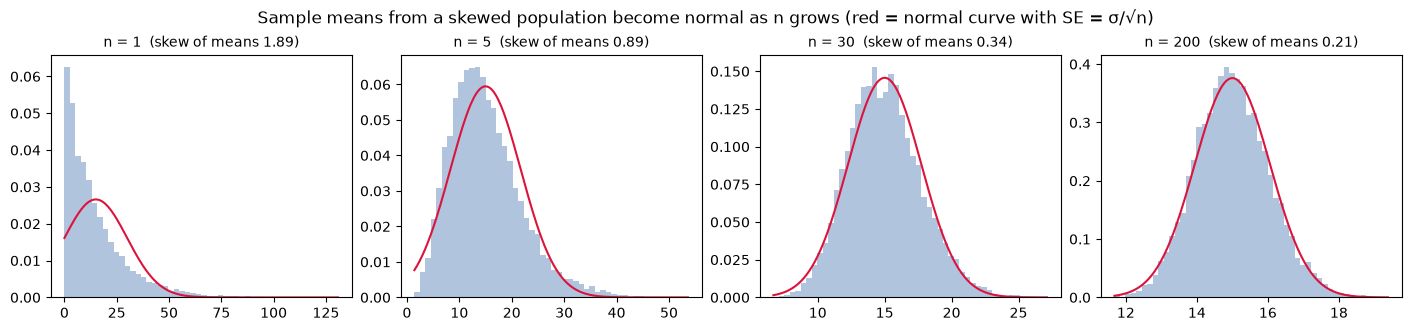

In [14]:
population = stats.expon(scale=15)
n_experiments = 10_000
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), layout="constrained")

for ax, n in zip(axes, [1, 5, 30, 200]):
    sample_means = population.rvs(size=(n_experiments, n), random_state=rng).mean(axis=1)
    se_theory = population.std() / np.sqrt(n)
    ax.hist(sample_means, bins=50, density=True, color="lightsteelblue")
    grid = np.linspace(sample_means.min(), sample_means.max(), 200)
    ax.plot(grid, stats.norm(population.mean(), se_theory).pdf(grid), color="crimson")
    ax.set_title(f"n = {n}  (skew of means {stats.skew(sample_means):.2f})", fontsize=10)
    print(f"n = {n:>3}: mean of sample means {sample_means.mean():6.2f} | std of sample means {sample_means.std():5.2f} | σ/√n = {se_theory:5.2f}")

fig.suptitle("Sample means from a skewed population become normal as n grows (red = normal curve with SE = σ/√n)")
plt.show()

**Where the CLT fails:** it needs a finite variance. For the heavy-tailed **Cauchy** distribution the average of 1,000 values is no more stable than the average of 10:

In [15]:
for n in (10, 1_000):
    cauchy_means = stats.cauchy.rvs(size=(2_000, n), random_state=rng).mean(axis=1)
    print(f"Cauchy, n = {n:>5}: IQR of the sample means = {stats.iqr(cauchy_means):.2f}")

normal_means = {n: stats.norm.rvs(size=(2_000, n), random_state=rng).mean(axis=1) for n in (10, 1_000)}
print(f"Normal, IQR of sample means: n=10 → {stats.iqr(normal_means[10]):.3f}, n=1000 → {stats.iqr(normal_means[1_000]):.3f}")

Cauchy, n =    10: IQR of the sample means = 2.02
Cauchy, n =  1000: IQR of the sample means = 2.06
Normal, IQR of sample means: n=10 → 0.397, n=1000 → 0.044


Real metrics like revenue per user are not Cauchy, but they can be heavy-tailed enough that the CLT needs **much** larger samples — keep that in mind for A/B tests on revenue.

> 💡 **Interview angle:** "State the CLT and why it matters for A/B testing." — conversion rate is a mean of 0/1 values, so with enough users its sampling distribution is normal; that justifies z-tests and CIs. Common trap: the CLT says the **means** become normal, *not* the data.

## 6. Confidence Intervals: t-Based and Bootstrap 🟡

A point estimate ("mean tip = 16.1%") hides uncertainty. A **95% confidence interval** is a range built by a procedure that captures the true value in **95% of repeated samples**.

**t-interval for a mean:** $\bar{x} \pm t^{*}_{n-1} \cdot \dfrac{s}{\sqrt{n}}$

We use the **t distribution** (not the normal's 1.96) because we *estimate* σ with $s$, which adds uncertainty; its critical value $t^{*}$ is larger for small n and approaches 1.96 as n grows.

In [16]:
tip_pct = tips["tip_pct"].to_numpy()
n = len(tip_pct)
mean, sd = tip_pct.mean(), tip_pct.std(ddof=1)
se = sd / np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n - 1)
ci_manual = (mean - t_crit * se, mean + t_crit * se)
ci_scipy = stats.ttest_1samp(tip_pct, popmean=0).confidence_interval(confidence_level=0.95)

print(f"mean tip = {mean:.2%}, SE = {se:.4f}, t* = {t_crit:.3f} (vs 1.96 for the normal)")
print(f"95% CI by hand : [{ci_manual[0]:.2%}, {ci_manual[1]:.2%}]")
print(f"95% CI by scipy: [{ci_scipy.low:.2%}, {ci_scipy.high:.2%}]")
assert np.allclose(ci_manual, (ci_scipy.low, ci_scipy.high))

for df in (4, 14, 29, 99):
    print(f"t* for n = {df + 1:>3}: {stats.t.ppf(0.975, df):.3f}")

mean tip = 16.08%, SE = 0.0039, t* = 1.970 (vs 1.96 for the normal)
95% CI by hand : [15.31%, 16.85%]
95% CI by scipy: [15.31%, 16.85%]
t* for n =   5: 2.776
t* for n =  15: 2.145
t* for n =  30: 2.045
t* for n = 100: 1.984


**What does "95%" really mean?** Let's *simulate* it: draw 1,000 samples (n = 15) from a population whose mean we know (50), build an interval from each, and count how many contain 50. We also try the wrong critical value (1.96) to see why small samples need t.

t-intervals contain the true mean 95.3% of the time (target 95%)
z-intervals (1.96) contain it only 93.1% of the time with n = 15


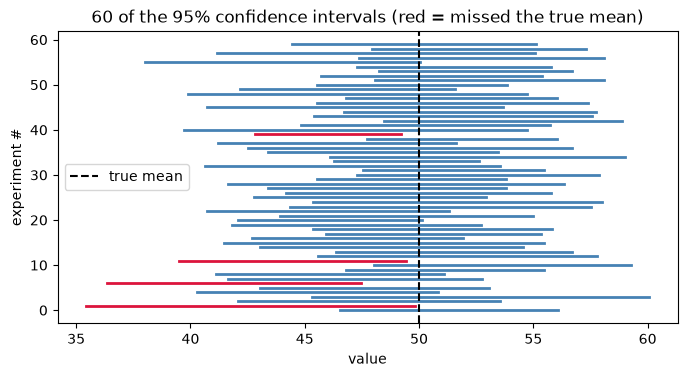

In [17]:
true_mean, true_sd, n_small, n_intervals = 50, 10, 15, 1_000
samples = rng.normal(true_mean, true_sd, size=(n_intervals, n_small))
means = samples.mean(axis=1)
ses = samples.std(axis=1, ddof=1) / np.sqrt(n_small)

t_star = stats.t.ppf(0.975, df=n_small - 1)
low, high = means - t_star * ses, means + t_star * ses
covered = (low <= true_mean) & (true_mean <= high)
covered_z = (means - 1.96 * ses <= true_mean) & (true_mean <= means + 1.96 * ses)
print(f"t-intervals contain the true mean {covered.mean():.1%} of the time (target 95%)")
print(f"z-intervals (1.96) contain it only {covered_z.mean():.1%} of the time with n = {n_small}")

fig, ax = plt.subplots(figsize=(8, 3.8))
for i in range(60):
    ax.plot([low[i], high[i]], [i, i], color="steelblue" if covered[i] else "crimson", lw=2)
ax.axvline(true_mean, color="black", ls="--", label="true mean")
ax.set(xlabel="value", ylabel="experiment #", title="60 of the 95% confidence intervals (red = missed the true mean)")
ax.legend()
plt.show()

### The bootstrap — a CI for (almost) any statistic

There's no simple formula for the CI of a **median**, a **90th percentile**, or an **AUC**. The **bootstrap** fakes "repeating the experiment" using only your sample:

1. Resample n rows **with replacement** from your data (some rows repeat, some are left out).
2. Compute the statistic on that resample.
3. Repeat thousands of times; the middle 95% of those values is a **percentile bootstrap CI**.

`scipy.stats.bootstrap` does this; its default `method="BCa"` also corrects for bias and skew.

In [18]:
median_boot = stats.bootstrap((bills.to_numpy(),), np.median, confidence_level=0.95, n_resamples=9_999, rng=rng)
ci = median_boot.confidence_interval
print(f"median bill = ${bills.median():.2f} | 95% bootstrap CI (BCa) [${ci.low:.2f}, ${ci.high:.2f}] | bootstrap SE {median_boot.standard_error:.2f}")

mean_boot = stats.bootstrap((tip_pct,), np.mean, n_resamples=9_999, rng=rng)
print(f"mean tip %: bootstrap CI [{mean_boot.confidence_interval.low:.2%}, {mean_boot.confidence_interval.high:.2%}] "
      f"vs t-interval [{ci_scipy.low:.2%}, {ci_scipy.high:.2%}]")

p90_boot = stats.bootstrap((bills.to_numpy(),), lambda x, axis: np.percentile(x, 90, axis=axis), n_resamples=9_999, rng=rng)
print(f"90th percentile bill = ${np.percentile(bills, 90):.2f} | 95% CI [${p90_boot.confidence_interval.low:.2f}, ${p90_boot.confidence_interval.high:.2f}]")

median bill = $17.80 | 95% bootstrap CI (BCa) [$16.49, $18.68] | bootstrap SE 0.53


mean tip %: bootstrap CI [15.41%, 16.99%] vs t-interval [15.31%, 16.85%]
90th percentile bill = $32.24 | 95% CI [$29.58, $34.98]


The bootstrap assumes your sample **represents the population** and rows are **independent**. It struggles with tiny samples, extremes like the maximum, and time series (use a *block* bootstrap there).

### ✍️ Your Turn

Compute the 95% **t-based** CI for the mean of `scores` below. Store `(low, high)` in `scores_ci`.

In [19]:
scores = np.array([12, 15, 11, 14, 13, 16, 12, 15])
scores_ci = None  # TODO: your code here
check("scores_ci", scores_ci, [12.017893, 14.982107], hint="mean ± stats.t.ppf(0.975, df=n-1) * std(ddof=1)/sqrt(n).")

⏳ scores_ci: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
scores = np.array([12, 15, 11, 14, 13, 16, 12, 15])
se_scores = scores.std(ddof=1) / np.sqrt(len(scores))
t_star = stats.t.ppf(0.975, df=len(scores) - 1)
scores_ci = (scores.mean() - t_star * se_scores, scores.mean() + t_star * se_scores)
check("scores_ci", scores_ci, [12.017893, 14.982107])

res = stats.ttest_1samp(scores, popmean=0).confidence_interval()   # same interval from scipy
check("scores_ci (scipy)", (res.low, res.high), [12.017893, 14.982107])
```
</details>

> 💡 **Interview angle:** "Interpret a 95% CI." — ✅ "If we repeated the study many times, 95% of intervals built this way would contain the true value." ❌ "There's a 95% probability the true value is in *this* interval" (that's a Bayesian *credible* interval). Bonus: "How would you get a CI for the AUC of a model?" → bootstrap the test set.

## 7. Hypothesis Testing Done Right 🟡

A hypothesis test is a **courtroom**:

| Courtroom | Statistics |
|---|---|
| "Innocent until proven guilty" | **Null hypothesis H₀**: no effect / no difference |
| The prosecutor's claim | **Alternative H₁**: there is an effect |
| "Beyond reasonable doubt" | **Significance level α** (e.g. 0.05), chosen *before* looking |
| How surprising is the evidence *if innocent*? | **p-value** |
| "Not guilty" ≠ "innocent" | failing to reject H₀ ≠ proving no effect |

**Definition:** the **p-value** is the probability of getting data **at least as extreme** as what you observed, **assuming H₀ is true**.

**Example:** a coin lands heads 60 times in 100 flips. Is it biased? H₀: p = 0.5.

In [20]:
coin_test = stats.binomtest(k=60, n=100, p=0.5, alternative="two-sided")
print(f"exact binomial test p-value = {coin_test.pvalue:.4f}")

# The same number by brute force: how often does a FAIR coin give a result at least as far from 50?
fair_heads = rng.binomial(n=100, p=0.5, size=200_000)
print(f"simulated: fair coin lands ≥ 10 away from 50 in {(np.abs(fair_heads - 50) >= 10).mean():.4f} of experiments")

if coin_test.pvalue < ALPHA:
    print(f"p < {ALPHA}: reject H₀ — evidence the coin is biased")
else:
    print(f"p ≥ {ALPHA}: fail to reject H₀ — 60/100 is not surprising enough for a fair coin (this does NOT prove it is fair)")

exact binomial test p-value = 0.0569


simulated: fair coin lands ≥ 10 away from 50 in 0.0565 of experiments
p ≥ 0.05: fail to reject H₀ — 60/100 is not surprising enough for a fair coin (this does NOT prove it is fair)


**Say it right** (p = 0.057 here):

| ✅ Correct | ❌ Wrong |
|---|---|
| "If the coin were fair, a result at least this extreme would happen about 5.7% of the time." | "There is a 5.7% chance the coin is fair." |
| "The data are not strong enough evidence at α = 0.05." | "The coin is fair." / "p > 0.05 proves no effect." |
| "A tiny p-value with a huge sample may be a tiny effect — check the effect size." | "Smaller p-value = bigger or more important effect." |

### Under H₀, p-values are uniform

If there is truly no effect, every p-value between 0 and 1 is equally likely — so you get p < 0.05 **5% of the time by pure chance**. That 5% is the **Type I error rate**. Let's run 10,000 "A/A tests" (two groups from the *same* population):

share of A/A tests with p < 0.05: 5.14% (expected ≈ 5%)


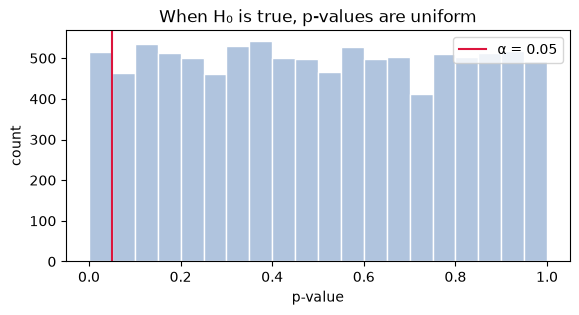

In [21]:
group_a = rng.normal(100, 15, size=(10_000, 50))
group_b = rng.normal(100, 15, size=(10_000, 50))
p_null = stats.ttest_ind(group_a, group_b, axis=1, equal_var=False).pvalue
print(f"share of A/A tests with p < 0.05: {(p_null < 0.05).mean():.2%} (expected ≈ 5%)")

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.hist(p_null, bins=20, color="lightsteelblue", edgecolor="white")
ax.axvline(0.05, color="crimson", label="α = 0.05")
ax.set(xlabel="p-value", ylabel="count", title="When H₀ is true, p-values are uniform")
ax.legend()
plt.show()

| | H₀ true (no effect) | H₁ true (real effect) |
|---|---|---|
| **Reject H₀** | ❌ **Type I error** (false positive), rate = α | ✅ correct — probability = **power** |
| **Don't reject** | ✅ correct | ❌ **Type II error** (false negative), rate = β = 1 − power |

### Why "p < 0.05" can still be wrong most of the time

The p-value is $P(\text{data} \mid H_0)$, not $P(H_0 \mid \text{data})$ — that needs Bayes and a **prior**. Suppose only **10%** of the ideas we test really work (effect d = 0.5, 64 users per group). Among the "significant" results, how many are false?

In [22]:
n_studies, share_real, n_per_group = 10_000, 0.10, 64
is_real = rng.random(n_studies) < share_real
true_effect = np.where(is_real, 0.5, 0.0)[:, None]
control = rng.normal(0, 1, size=(n_studies, n_per_group))
treatment = rng.normal(0, 1, size=(n_studies, n_per_group)) + true_effect
significant = stats.ttest_ind(treatment, control, axis=1, equal_var=False).pvalue < ALPHA

print(f"power on real effects        : {significant[is_real].mean():.1%}")
print(f"false-positive rate on nulls : {significant[~is_real].mean():.1%}")
print(f"share of 'significant' results that are FALSE: {(significant & ~is_real).sum() / significant.sum():.1%}")

power on real effects        : 77.6%
false-positive rate on nulls : 4.9%
share of 'significant' results that are FALSE: 36.0%


### ✍️ Your Turn

A z-test statistic came out as **z = 2.1**. Compute the **two-sided** p-value and store it in `p_two_sided`.

In [23]:
p_two_sided = None  # TODO: your code here
check("p_two_sided", p_two_sided, 0.0357288, hint="Two-sided → both tails: 2 * stats.norm.sf(abs(z)).")

⏳ p_two_sided: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
z = 2.1
p_two_sided = 2 * stats.norm.sf(abs(z))
check("p_two_sided", p_two_sided, 0.0357288)
```

`sf` (= 1 − cdf) is more accurate than `1 - cdf` for extreme z values.
</details>

> 💡 **Interview angle:** "What is a p-value?" — give the definition *with* "assuming the null is true", then volunteer the two classic misreadings (it is not the probability H₀ is true; non-significant is not proof of no effect). That alone puts you ahead of most candidates.

## 8. Power and Sample Size 🟡

**Power** = the probability your test detects an effect **that really exists**. Industry standard: **80%**. Four knobs:

| Knob | Effect on power |
|---|---|
| Effect size ↑ (bigger difference) | power ↑ |
| Sample size n ↑ | power ↑ |
| Noise (σ) ↑ | power ↓ |
| α ↑ (looser threshold) | power ↑ — but more false positives |

**Effect size** for means is often **Cohen's d** = difference ÷ standard deviation (rough guide: 0.2 small, 0.5 medium, 0.8 large). For proportions statsmodels uses **Cohen's h**.

**Do the power analysis *before* collecting data** — afterwards it's too late to fix an underpowered study.

In [24]:
power_analysis = TTestIndPower()
n_needed = power_analysis.solve_power(effect_size=0.5, alpha=ALPHA, power=0.80, alternative="two-sided")
print(f"statsmodels: need {np.ceil(n_needed):.0f} per group to detect d = 0.5 with 80% power")

# The textbook normal-approximation formula: n = 2 (z_{1-α/2} + z_{power})² / d²
z_alpha, z_power = stats.norm.ppf(1 - ALPHA / 2), stats.norm.ppf(0.80)
print(f"formula    : n ≈ 2 × ({z_alpha:.2f} + {z_power:.2f})² / 0.5² = {2 * (z_alpha + z_power) ** 2 / 0.5 ** 2:.1f} (t-test needs slightly more)")

# Verify by simulation: run 5,000 experiments with a real effect of d = 0.5
n_group = int(np.ceil(n_needed))
sim_a = rng.normal(0.0, 1, size=(5_000, n_group))
sim_b = rng.normal(0.5, 1, size=(5_000, n_group))
sim_power = (stats.ttest_ind(sim_b, sim_a, axis=1, equal_var=False).pvalue < ALPHA).mean()
print(f"simulation : {sim_power:.1%} of experiments detected the effect")

statsmodels: need 64 per group to detect d = 0.5 with 80% power
formula    : n ≈ 2 × (1.96 + 0.84)² / 0.5² = 62.8 (t-test needs slightly more)
simulation : 80.5% of experiments detected the effect


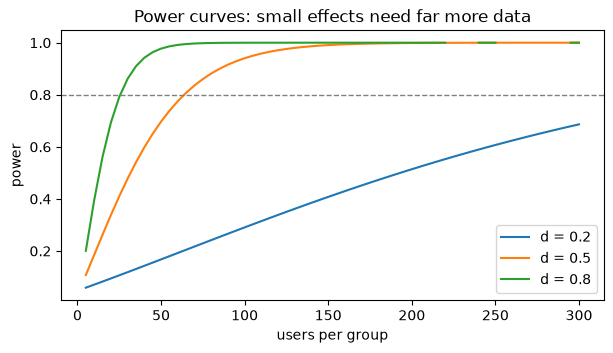

In [25]:
sizes = np.arange(5, 301, 5)
fig, ax = plt.subplots(figsize=(7, 3.5))
for d in (0.2, 0.5, 0.8):
    ax.plot(sizes, power_analysis.power(effect_size=d, nobs1=sizes, alpha=ALPHA), label=f"d = {d}")
ax.axhline(0.8, color="gray", ls="--", lw=1)
ax.set(xlabel="users per group", ylabel="power", title="Power curves: small effects need far more data")
ax.legend()
plt.show()

**Proportions (conversion rates)** — the most common A/B metric. Notice how the required sample explodes as the minimum detectable effect (**MDE**) shrinks: halving the MDE needs about **4×** the users.

In [26]:
baseline = 0.10
rows = []
for mde in (0.02, 0.01, 0.005):
    h = proportion_effectsize(baseline + mde, baseline)
    n_prop = NormalIndPower().solve_power(effect_size=h, alpha=ALPHA, power=0.80)
    rows.append({"baseline": baseline, "MDE (absolute)": mde, "relative lift": f"{mde / baseline:.0%}",
                 "users per group": int(np.ceil(n_prop))})
pd.DataFrame(rows)

,baseline,MDE (absolute),relative lift,users per group
0,0.1,0.020,20%,3835
1,0.1,0.010,10%,14745
2,0.1,0.005,5%,57756


### ✍️ Your Turn

How many users **per group** do you need to detect **d = 0.3** with **90% power** at α = 0.05 (two-sided t-test)? Store the (unrounded or rounded-up) number in `n_per_group_needed`.

In [27]:
n_per_group_needed = None  # TODO: your code here
check("n_per_group_needed", n_per_group_needed, 234.4627, hint="TTestIndPower().solve_power(effect_size=..., alpha=..., power=...)", rtol=0.01)

⏳ n_per_group_needed: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_per_group_needed = TTestIndPower().solve_power(effect_size=0.3, alpha=0.05, power=0.90)
check("n_per_group_needed", n_per_group_needed, 234.4627, rtol=0.01)   # round up → 235 per group
```
</details>

> 💡 **Interview angle:** "How long should we run this A/B test?" — pick α, power, and the **minimum effect worth detecting**; compute n per group; divide by daily eligible traffic; **round up to full weeks** to cover weekday/weekend cycles. Mention that variance reduction (e.g. CUPED) lowers n.

## 9. t-Tests: One-Sample, Paired, and Welch 🟡

| Test | Question | scipy |
|---|---|---|
| **One-sample** | Is the mean different from a fixed number? | `stats.ttest_1samp(x, popmean)` |
| **Paired** | Did the *same units* change (before/after, two drugs on the same patients)? | `stats.ttest_rel(after, before)` |
| **Welch (two-sample)** | Do two *independent* groups have different means? | `stats.ttest_ind(a, b, equal_var=False)` |

**Assumptions:** independent observations, and a sample mean that is roughly normal (true for moderate n by the CLT, unless the data are extremely skewed or heavy-tailed). **Use Welch by default** — the classic Student t-test assumes equal variances, and Welch loses almost nothing when they are equal.

In [28]:
def report(name, result, alpha=ALPHA):
    ci = result.confidence_interval()
    verdict = "reject H₀" if result.pvalue < alpha else "fail to reject H₀ (not proof of no effect)"
    print(f"{name}: t = {result.statistic:.3f}, df = {result.df:.1f}, p = {result.pvalue:.4g}, "
          f"95% CI [{ci.low:.4f}, {ci.high:.4f}] → {verdict}")


# One-sample: is the average tip different from the common 15% guideline?
report("one-sample (tip % vs 15%)", stats.ttest_1samp(tips["tip_pct"], popmean=0.15))
print(f"   sample mean tip = {tips['tip_pct'].mean():.2%}")

one-sample (tip % vs 15%): t = 2.763, df = 243.0, p = 0.006166, 95% CI [0.1531, 0.1685] → reject H₀
   sample mean tip = 16.08%


**Paired test on real data:** Student's famous 1908 **sleep** dataset — extra hours of sleep for the **same 10 patients** on two different drugs.

In [29]:
sleep = load_csv("https://vincentarelbundock.github.io/Rdatasets/csv/datasets/sleep.csv", "sleep.csv")
sleep_wide = sleep.pivot(index="ID", columns="group", values="extra")
sleep_wide.columns = ["drug1", "drug2"]
drug1, drug2 = sleep_wide["drug1"].to_numpy(), sleep_wide["drug2"].to_numpy()
sleep_wide.assign(difference=drug2 - drug1).T

ID,1,2,3,4,5,6,7,8,9,10
drug1,0.7,-1.6,-0.2,-1.2,-0.1,3.4,3.7,0.8,0.0,2.0
drug2,1.9,0.8,1.1,0.1,-0.1,4.4,5.5,1.6,4.6,3.4
difference,1.2,2.4,1.3,1.3,0.0,1.0,1.8,0.8,4.6,1.4


In [30]:
report("paired     (drug2 − drug1)", stats.ttest_rel(drug2, drug1))
report("independent (wrong here)  ", stats.ttest_ind(drug2, drug1, equal_var=False))
print(f"\nstd within each drug group: {drug1.std(ddof=1):.2f}, {drug2.std(ddof=1):.2f} | std of the paired differences: {(drug2 - drug1).std(ddof=1):.2f}")

paired     (drug2 − drug1): t = 4.062, df = 9.0, p = 0.002833, 95% CI [0.7001, 2.4599] → reject H₀
independent (wrong here)  : t = 1.861, df = 17.8, p = 0.07939, 95% CI [-0.2055, 3.3655] → fail to reject H₀ (not proof of no effect)

std within each drug group: 1.79, 2.00 | std of the paired differences: 1.23


Pairing removes the patient-to-patient variation (some people just sleep more), so the noise shrinks and the same data give much stronger evidence.

**Welch's test on independent groups:** do dinner bills differ from lunch bills? Also report an **effect size** — the p-value alone doesn't say how big the difference is.

In [31]:
def cohens_d(a, b):
    pooled_sd = np.sqrt(((len(a) - 1) * np.var(a, ddof=1) + (len(b) - 1) * np.var(b, ddof=1)) / (len(a) + len(b) - 2))
    return (np.mean(a) - np.mean(b)) / pooled_sd


dinner = tips.loc[tips["time"] == "Dinner", "total_bill"].to_numpy()
lunch = tips.loc[tips["time"] == "Lunch", "total_bill"].to_numpy()
report("Welch (dinner − lunch bill)", stats.ttest_ind(dinner, lunch, equal_var=False))
print(f"   means: dinner ${dinner.mean():.2f} (n={len(dinner)}), lunch ${lunch.mean():.2f} (n={len(lunch)}) | Cohen's d = {cohens_d(dinner, lunch):.2f}")

smokers = tips.loc[tips["smoker"] == "Yes", "tip_pct"].to_numpy()
non_smokers = tips.loc[tips["smoker"] == "No", "tip_pct"].to_numpy()
report("Welch (smoker − non-smoker tip %)", stats.ttest_ind(smokers, non_smokers, equal_var=False))
print(f"   Cohen's d = {cohens_d(smokers, non_smokers):.2f}")

Welch (dinner − lunch bill): t = 3.123, df = 143.3, p = 0.002167, 95% CI [1.3319, 5.9251] → reject H₀
   means: dinner $20.80 (n=176), lunch $17.17 (n=68) | Cohen's d = 0.41
Welch (smoker − non-smoker tip %): t = 0.411, df = 117.3, p = 0.6817, 95% CI [-0.0148, 0.0225] → fail to reject H₀ (not proof of no effect)
   Cohen's d = 0.06


### ✍️ Your Turn

Eight servers had their response time (seconds) measured **before and after** a software update. Run the correct test and store its **p-value** in `p_update`.

In [32]:
before = np.array([72, 80, 65, 90, 77, 84, 69, 75])
after = np.array([70, 77, 66, 86, 74, 80, 68, 72])
p_update = None  # TODO: your code here
check("p_update", p_update, 0.0052792, hint="Same servers measured twice → paired: stats.ttest_rel(after, before).pvalue")

⏳ p_update: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
before = np.array([72, 80, 65, 90, 77, 84, 69, 75])
after = np.array([70, 77, 66, 86, 74, 80, 68, 72])
p_update = stats.ttest_rel(after, before).pvalue
check("p_update", p_update, 0.0052792)
```

An independent test would ignore that each pair shares a server and give a much larger p-value.
</details>

> 💡 **Interview angle:** "Student vs Welch t-test?" — Welch doesn't assume equal variances and is the safe default (R's `t.test` uses it by default; in scipy pass `equal_var=False`). "When is a paired test right?" — whenever each observation in one group is naturally matched to one in the other.

## 10. Chi-Square and Non-Parametric Tests 🟡

### Chi-square test of independence (categorical × categorical)

Is survival on the Titanic independent of sex? The test compares the **observed** counts in a contingency table with the counts **expected** if the two variables were independent. Rule of thumb: expected counts should be ≥ 5 in each cell.

In [33]:
titanic = sns.load_dataset("titanic")
table = pd.crosstab(titanic["sex"], titanic["survived"])
chi2 = stats.chi2_contingency(table)             # applies Yates' continuity correction for 2×2 tables
print(table, "\n")
print(f"survival rate: female {titanic.loc[titanic.sex == 'female', 'survived'].mean():.1%}, male {titanic.loc[titanic.sex == 'male', 'survived'].mean():.1%}")
print(f"chi² = {chi2.statistic:.1f}, dof = {chi2.dof}, p = {chi2.pvalue:.2e}, min expected count = {chi2.expected_freq.min():.0f}")
print(f"Cramér's V (effect size, 0–1) = {stats.contingency.association(table, method='cramer'):.2f}")

survived    0    1
sex               
female     81  233
male      468  109 

survival rate: female 74.2%, male 18.9%
chi² = 260.7, dof = 1, p = 1.20e-58, min expected count = 121
Cramér's V (effect size, 0–1) = 0.54


**Goodness-of-fit** asks whether counts match expected proportions — e.g. whether an A/B split designed as 50/50 really is. Experimentation teams usually flag a *sample ratio mismatch* only at a strict threshold such as p < 0.001, because the check runs on every experiment. *(Illustrative counts.)*

In [34]:
for observed_split in (np.array([5_040, 4_960]), np.array([5_200, 4_800])):
    gof = stats.chisquare(observed_split, f_exp=[observed_split.sum() / 2] * 2)
    verdict = "⚠️ sample ratio mismatch — investigate" if gof.pvalue < 0.001 else "consistent with a 50/50 split"
    print(f"split {observed_split} → chi² = {gof.statistic:.2f}, p = {gof.pvalue:.2g} → {verdict}")

split [5040 4960] → chi² = 0.64, p = 0.42 → consistent with a 50/50 split
split [5200 4800] → chi² = 16.00, p = 6.3e-05 → ⚠️ sample ratio mismatch — investigate


### Mann–Whitney U (a rank-based alternative to the two-sample t-test)

**Non-parametric** tests don't assume a distribution shape. Mann–Whitney ranks all values together and asks whether one group **tends to have larger values** — formally, whether $P(X > Y) \ne 0.5$. Use it for ordinal data (ratings), small skewed samples, or data with outliers. It is *not* strictly a test of medians, and it answers a different question than a test of means.

In [35]:
mw = stats.mannwhitneyu(dinner, lunch, alternative="two-sided")
print(f"Mann–Whitney: U = {mw.statistic:.0f}, p = {mw.pvalue:.4f}")
print(f"P(random dinner bill > random lunch bill) ≈ U / (n₁·n₂) = {mw.statistic / (len(dinner) * len(lunch)):.2f}")

# Robustness: add ONE typo ($5079) to the lunch bills and re-run both tests
lunch_typo = np.append(lunch, 5079.0)
welch_clean = stats.ttest_ind(dinner, lunch, equal_var=False)
welch_typo = stats.ttest_ind(dinner, lunch_typo, equal_var=False)
mw_typo = stats.mannwhitneyu(dinner, lunch_typo, alternative="two-sided")
print(f"\nWelch t-test p: clean {welch_clean.pvalue:.4f} → with typo {welch_typo.pvalue:.4f} (t flipped sign: {np.sign(welch_clean.statistic) != np.sign(welch_typo.statistic)})")
print(f"Mann–Whitney p: clean {mw.pvalue:.4f} → with typo {mw_typo.pvalue:.4f}")

Mann–Whitney: U = 7588, p = 0.0012
P(random dinner bill > random lunch bill) ≈ U / (n₁·n₂) = 0.63

Welch t-test p: clean 0.0022 → with typo 0.3453 (t flipped sign: True)
Mann–Whitney p: clean 0.0012 → with typo 0.0024


> 💡 **Interview angle:** "t-test or Mann–Whitney?" — t-test (Welch) compares **means**, which the business usually cares about (revenue per user), and is fine for large samples; Mann–Whitney compares **rank/ordering**, is robust to outliers, and suits ordinal or small skewed data. For heavy-tailed revenue in big A/B tests, a bootstrap or winsorized mean is often better than either.

## 11. Correlation, Causation, and Simpson's Paradox 🟡

**Correlation** measures how two variables move together, from −1 to +1.

- **Pearson r** — strength of a **linear** relationship; sensitive to outliers.
- **Spearman ρ** — Pearson on the **ranks**; captures any **monotonic** relationship and resists outliers.

Real data first: penguin flipper length vs body mass.

In [36]:
penguins = sns.load_dataset("penguins").dropna()
pearson = stats.pearsonr(penguins["flipper_length_mm"], penguins["body_mass_g"])
spearman = stats.spearmanr(penguins["flipper_length_mm"], penguins["body_mass_g"])
pci = pearson.confidence_interval()
print(f"Pearson r = {pearson.statistic:.3f} (95% CI [{pci.low:.3f}, {pci.high:.3f}]) | Spearman ρ = {spearman.statistic:.3f}")

# Controlled examples of what correlation can and can't see
x = np.linspace(0, 5, 50)
print(f"\ny = exp(x)  (monotonic, curved): Pearson {stats.pearsonr(x, np.exp(x)).statistic:.2f}, Spearman {stats.spearmanr(x, np.exp(x)).statistic:.2f}")
x_sym = np.linspace(-3, 3, 50)
print(f"y = x²      (perfectly dependent!): Pearson {stats.pearsonr(x_sym, x_sym ** 2).statistic:.2f}  ← zero correlation ≠ independence")
noise_x, noise_y = rng.normal(size=30), rng.normal(size=30)
print(f"30 random points: Pearson {stats.pearsonr(noise_x, noise_y).statistic:.2f} → add one outlier (10, 10): "
      f"Pearson {stats.pearsonr(np.append(noise_x, 10), np.append(noise_y, 10)).statistic:.2f}, "
      f"Spearman {stats.spearmanr(np.append(noise_x, 10), np.append(noise_y, 10)).statistic:.2f}")

Pearson r = 0.873 (95% CI [0.845, 0.896]) | Spearman ρ = 0.840

y = exp(x)  (monotonic, curved): Pearson 0.85, Spearman 1.00
y = x²      (perfectly dependent!): Pearson -0.00  ← zero correlation ≠ independence
30 random points: Pearson 0.22 → add one outlier (10, 10): Pearson 0.78, Spearman 0.38


### Simpson's paradox — a trend that reverses when you split the data

**Example 1 (penguins):** across *all* penguins, longer bills go with *shallower* bills. Within *each species* it's the opposite. Species is a **confounder**: it affects both variables.

all penguins: r = -0.23
   Adelie: r = +0.39
Chinstrap: r = +0.65
   Gentoo: r = +0.65


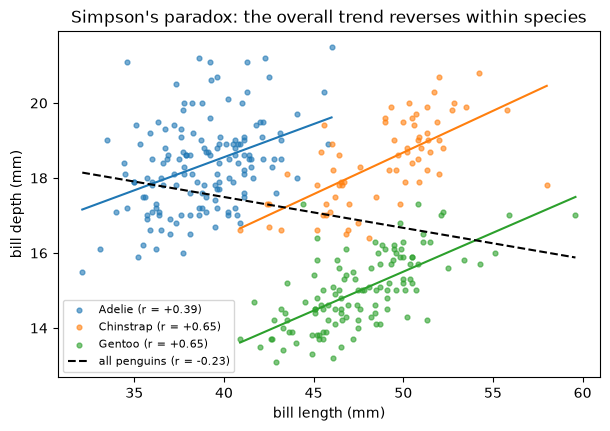

In [37]:
overall_r = stats.pearsonr(penguins["bill_length_mm"], penguins["bill_depth_mm"]).statistic
print(f"all penguins: r = {overall_r:+.2f}")
fig, ax = plt.subplots(figsize=(7, 4.5))
for i, (species, grp) in enumerate(penguins.groupby("species")):
    r = stats.pearsonr(grp["bill_length_mm"], grp["bill_depth_mm"]).statistic
    print(f"{species:>9}: r = {r:+.2f}")
    ax.scatter(grp["bill_length_mm"], grp["bill_depth_mm"], s=12, alpha=0.6, color=f"C{i}", label=f"{species} (r = {r:+.2f})")
    slope, intercept = np.polyfit(grp["bill_length_mm"], grp["bill_depth_mm"], deg=1)
    xs = np.linspace(grp["bill_length_mm"].min(), grp["bill_length_mm"].max(), 10)
    ax.plot(xs, slope * xs + intercept, color=f"C{i}")
slope, intercept = np.polyfit(penguins["bill_length_mm"], penguins["bill_depth_mm"], deg=1)
xs = np.linspace(penguins["bill_length_mm"].min(), penguins["bill_length_mm"].max(), 10)
ax.plot(xs, slope * xs + intercept, "k--", label=f"all penguins (r = {overall_r:+.2f})")
ax.set(xlabel="bill length (mm)", ylabel="bill depth (mm)", title="Simpson's paradox: the overall trend reverses within species")
ax.legend(fontsize=8)
plt.show()

**Example 2 (UC Berkeley graduate admissions, 1973):** overall, men were admitted at a much higher rate than women. Department by department, the picture changes.

In [38]:
ucb = load_csv("https://vincentarelbundock.github.io/Rdatasets/csv/datasets/UCBAdmissions.csv", "ucb_admissions.csv")
counts = ucb.pivot_table(index=["Dept", "Gender"], columns="Admit", values="Freq", aggfunc="sum")
counts["applicants"] = counts["Admitted"] + counts["Rejected"]

overall = counts.groupby("Gender")[["Admitted", "applicants"]].sum()
overall_rate = overall["Admitted"] / overall["applicants"]
print(f"overall admission rate: men {overall_rate['Male']:.1%}, women {overall_rate['Female']:.1%}")

by_dept = (counts["Admitted"] / counts["applicants"]).unstack("Gender")
applicants = counts["applicants"].unstack("Gender")
by_dept["dept admit rate"] = counts.groupby("Dept")["Admitted"].sum() / applicants.sum(axis=1)
by_dept["share of applicants who are women"] = applicants["Female"] / applicants.sum(axis=1)
print(by_dept.round(3))

n_women_higher = (by_dept["Female"] > by_dept["Male"]).sum()
r_share = stats.pearsonr(by_dept["dept admit rate"], by_dept["share of applicants who are women"]).statistic
print(f"\nwomen had the higher admission rate in {n_women_higher} of {len(by_dept)} departments")
print(f"correlation between a department's admission rate and its share of women applicants: {r_share:+.2f}")

overall admission rate: men 44.5%, women 30.4%
Gender  Female   Male  dept admit rate  share of applicants who are women
Dept                                                                     
A        0.824  0.621            0.644                              0.116
B        0.680  0.630            0.632                              0.043
C        0.341  0.369            0.351                              0.646
D        0.349  0.331            0.340                              0.473
E        0.239  0.277            0.252                              0.673
F        0.070  0.059            0.064                              0.478

women had the higher admission rate in 4 of 6 departments
correlation between a department's admission rate and its share of women applicants: -0.79


Women applied more often to departments that admitted *everyone* at low rates, which dragged their overall rate down. The aggregate comparison mixed up "who applied where" with "how applicants were treated".

**Correlation is not causation.** A correlation can come from a **confounder** (summer causes both ice-cream sales and drownings), **reverse causation**, or **chance**. The cleanest way to establish causation is a **randomized experiment** — randomization balances confounders on average — which is exactly what an A/B test is. Without one, you need causal-inference tools (causal diagrams, matching, difference-in-differences, instrumental variables).

### ✍️ Your Turn

For `xs_turn = [1, 2, 3, 4, 5]` and `ys_turn = [2, 4, 8, 16, 1000]`, compute the **Spearman** correlation and store it in `rho_turn`. (Compare with Pearson afterwards.)

In [39]:
xs_turn = np.array([1, 2, 3, 4, 5])
ys_turn = np.array([2, 4, 8, 16, 1000])
rho_turn = None  # TODO: your code here
check("rho_turn", rho_turn, 1.0, hint="stats.spearmanr(xs_turn, ys_turn).statistic")

⏳ rho_turn: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
xs_turn = np.array([1, 2, 3, 4, 5])
ys_turn = np.array([2, 4, 8, 16, 1000])
rho_turn = stats.spearmanr(xs_turn, ys_turn).statistic
check("rho_turn", rho_turn, 1.0)
print(f"Pearson = {stats.pearsonr(xs_turn, ys_turn).statistic:.2f}")   # much lower: not a straight line
```

The ranks increase perfectly together, so Spearman is exactly 1, while Pearson is dragged down by the non-linear jump.
</details>

> 💡 **Interview angle:** "Users who use feature X retain better — should we push everyone to X?" — not from that correlation: engaged users both use X and retain (confounding/self-selection). Propose an A/B test, or a careful observational analysis that adjusts for engagement.

## 12. Multiple Testing: Bonferroni and Benjamini–Hochberg 🔴

Each test at α = 0.05 has a 5% false-positive chance. Run many tests and false positives become **almost certain**: $P(\text{at least one}) = 1 - (1 - \alpha)^m$.

In [40]:
for m in (1, 5, 20, 100):
    print(f"{m:>3} independent tests with no real effects → P(≥ 1 false positive) = {1 - (1 - ALPHA) ** m:.1%}")

# Simulate: 5,000 A/A experiments, each checking 20 independent metrics
aa_a = rng.normal(size=(5_000, 20, 30))
aa_b = rng.normal(size=(5_000, 20, 30))
aa_p = stats.ttest_ind(aa_a, aa_b, axis=2).pvalue
print(f"\nsimulated: {(aa_p < ALPHA).any(axis=1).mean():.1%} of A/A experiments found at least one 'significant' metric")

  1 independent tests with no real effects → P(≥ 1 false positive) = 5.0%
  5 independent tests with no real effects → P(≥ 1 false positive) = 22.6%
 20 independent tests with no real effects → P(≥ 1 false positive) = 64.2%
100 independent tests with no real effects → P(≥ 1 false positive) = 99.4%



simulated: 63.9% of A/A experiments found at least one 'significant' metric


| Method | Controls | Rule | Use when |
|---|---|---|---|
| **Bonferroni** | FWER — P(any false positive) ≤ α | reject if p < α / m | few tests; any false claim is costly |
| **Holm** | FWER, strictly more powerful than Bonferroni | compare sorted p-values to α/m, α/(m−1), … and stop at the first failure | same as Bonferroni — just better |
| **Benjamini–Hochberg (BH)** | FDR — expected share of false discoveries among discoveries ≤ q | sort p-values; find the largest k with $p_{(k)} \le \frac{k}{m} q$; reject the k smallest | screening many hypotheses (metrics, features, genes) |

A controlled simulation: 1,000 tests, of which 100 have a real effect.

In [41]:
m_tests, m_real, n_obs = 1_000, 100, 50
real_effect = np.zeros(m_tests, dtype=bool)
real_effect[:m_real] = True
x_ctrl = rng.normal(size=(m_tests, n_obs))
x_trt = rng.normal(size=(m_tests, n_obs)) + np.where(real_effect, 0.5, 0.0)[:, None]
pvals = stats.ttest_ind(x_trt, x_ctrl, axis=1).pvalue

decisions = {
    "no correction": pvals < ALPHA,
    "Bonferroni": multipletests(pvals, alpha=ALPHA, method="bonferroni")[0],
    "Holm": multipletests(pvals, alpha=ALPHA, method="holm")[0],
    "Benjamini–Hochberg": multipletests(pvals, alpha=ALPHA, method="fdr_bh")[0],
}
summary_rows = []
for method, reject in decisions.items():
    false_disc = int((reject & ~real_effect).sum())
    summary_rows.append({"method": method, "discoveries": int(reject.sum()), "true discoveries": int((reject & real_effect).sum()),
                         "false discoveries": false_disc, "false discovery proportion": false_disc / max(int(reject.sum()), 1)})
print(pd.DataFrame(summary_rows).round(3).to_string(index=False))

assert np.allclose(stats.false_discovery_control(pvals, method="bh"), multipletests(pvals, method="fdr_bh")[1])
print("\nscipy.stats.false_discovery_control gives the same BH-adjusted p-values as statsmodels ✅")

            method  discoveries  true discoveries  false discoveries  false discovery proportion
     no correction          124                73                 51                       0.411
        Bonferroni            9                 9                  0                       0.000
              Holm            9                 9                  0                       0.000
Benjamini–Hochberg           36                36                  0                       0.000

scipy.stats.false_discovery_control gives the same BH-adjusted p-values as statsmodels ✅


### ✍️ Your Turn

An experiment tracked 10 metrics with the p-values below. How many remain significant after a **Bonferroni** correction at α = 0.05? Store an integer in `n_bonferroni`.

In [42]:
metric_pvals = np.array([0.003, 0.02, 0.0004, 0.08, 0.006, 0.3, 0.045, 0.0049, 0.5, 0.011])
n_bonferroni = None  # TODO: your code here
check("n_bonferroni", n_bonferroni, 3, hint="Compare each p-value with 0.05 / number_of_tests and count.")

⏳ n_bonferroni: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
metric_pvals = np.array([0.003, 0.02, 0.0004, 0.08, 0.006, 0.3, 0.045, 0.0049, 0.5, 0.011])
n_bonferroni = int((metric_pvals < 0.05 / len(metric_pvals)).sum())
check("n_bonferroni", n_bonferroni, 3)
check("n_bonferroni (statsmodels)", multipletests(metric_pvals, method="bonferroni")[0].sum(), 3)
```

The threshold is 0.005, so only 0.0004, 0.003 and 0.0049 survive.
</details>

> 💡 **Interview angle:** "Your experiment moved 1 of 20 metrics with p = 0.03 — is it real?" — with 20 metrics you expect one false positive by chance. Pre-register a **primary metric**, treat others as secondary/guardrails, and correct (Holm or BH) when making claims on many.

## 13. Maximum Likelihood Estimation 🔴

**Likelihood** turns probability around: instead of "given the parameter, how likely are the data?", we fix the data and ask **"which parameter value makes these data most likely?"** That value is the **maximum likelihood estimate (MLE)**.

In practice we maximize the **log-likelihood** (sums instead of products — no numerical underflow) or, equivalently, *minimize the negative log-likelihood* — which is exactly what training a model does.

**Coin example:** 7 heads in 10 flips. Likelihood $L(p) = p^7 (1-p)^3$.

likelihood is maximized at p = 0.700 (= 7/10)


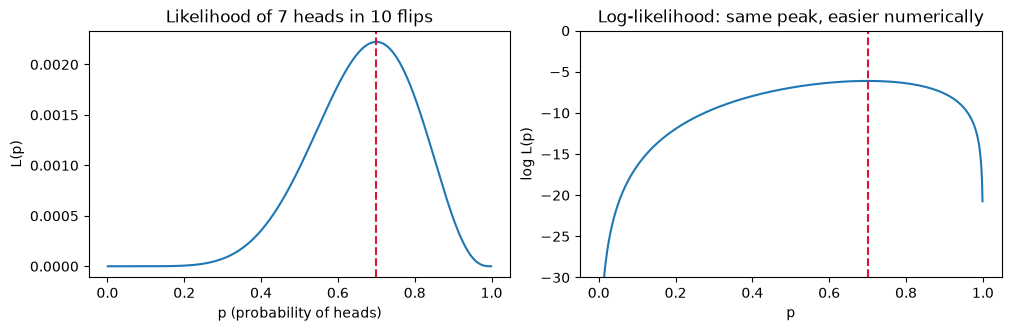

In [43]:
p_grid = np.linspace(0.001, 0.999, 999)
likelihood = p_grid ** 7 * (1 - p_grid) ** 3
log_likelihood = 7 * np.log(p_grid) + 3 * np.log(1 - p_grid)
print(f"likelihood is maximized at p = {p_grid[likelihood.argmax()]:.3f} (= 7/10)")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), layout="constrained")
axes[0].plot(p_grid, likelihood)
axes[0].set(xlabel="p (probability of heads)", ylabel="L(p)", title="Likelihood of 7 heads in 10 flips")
axes[1].plot(p_grid, log_likelihood)
axes[1].set(xlabel="p", ylabel="log L(p)", title="Log-likelihood: same peak, easier numerically", ylim=(-30, 0))
for ax in axes:
    ax.axvline(0.7, color="crimson", ls="--")
plt.show()

**Numerical MLE.** For most models there is no formula, so we minimize the negative log-likelihood with an optimizer. *Controlled example:* Poisson counts with a known true rate of 3.7 — the MLE should equal the sample mean.

In [44]:
from scipy.optimize import minimize_scalar

event_counts = stats.poisson.rvs(mu=3.7, size=200, random_state=rng)


def poisson_nll(lam):
    return -stats.poisson.logpmf(event_counts, lam).sum()


fit = minimize_scalar(poisson_nll, bounds=(0.01, 20), method="bounded")
print(f"numerical MLE λ̂ = {fit.x:.4f} | sample mean = {event_counts.mean():.4f} | true λ = 3.7")
assert np.isclose(fit.x, event_counts.mean(), atol=1e-3)

# Normal MLE on real data: Gentoo penguin flipper lengths
gentoo = penguins.loc[penguins["species"] == "Gentoo", "flipper_length_mm"].to_numpy()
mu_hat, sigma_hat = stats.norm.fit(gentoo)
print(f"Gentoo flippers: MLE μ̂ = {mu_hat:.2f} (sample mean {gentoo.mean():.2f}), σ̂ = {sigma_hat:.3f} "
      f"(std with ddof=0: {gentoo.std(ddof=0):.3f}, ddof=1: {gentoo.std(ddof=1):.3f})")
assert np.isclose(mu_hat, gentoo.mean()) and np.isclose(sigma_hat, gentoo.std(ddof=0))

numerical MLE λ̂ = 3.5500 | sample mean = 3.5500 | true λ = 3.7
Gentoo flippers: MLE μ̂ = 217.24 (sample mean 217.24), σ̂ = 6.558 (std with ddof=0: 6.558, ddof=1: 6.585)


Note the MLE of σ divides by **n** (ddof=0) — it is slightly biased; the unbiased sample std divides by n − 1.

**Why ML engineers care:** common loss functions *are* negative log-likelihoods.

| Loss | Is the NLL of… | Model |
|---|---|---|
| Mean squared error | Gaussian noise around the prediction | linear regression |
| Binary cross-entropy (log loss) | Bernoulli labels | logistic regression, sigmoid output |
| Categorical cross-entropy | Categorical labels | softmax classifiers, LLM next-token prediction |

Adding a Gaussian **prior** on the weights and maximizing the posterior (**MAP**) gives L2 regularization; a Laplace prior gives L1.

In [45]:
from sklearn.metrics import log_loss

y_labels = np.array([1, 0, 1, 1, 0])
p_pred = np.array([0.9, 0.2, 0.6, 0.8, 0.3])
bernoulli_nll = -np.mean(y_labels * np.log(p_pred) + (1 - y_labels) * np.log(1 - p_pred))
print(f"mean Bernoulli negative log-likelihood = {bernoulli_nll:.6f} | sklearn log_loss = {log_loss(y_labels, p_pred):.6f}")
assert np.isclose(bernoulli_nll, log_loss(y_labels, p_pred))

mean Bernoulli negative log-likelihood = 0.283830 | sklearn log_loss = 0.283830


> 💡 **Interview angle:** "Why do we use cross-entropy for classification?" — it is the negative log-likelihood of the labels under the model's predicted probabilities, so minimizing it is maximum likelihood. Bonus: MLE overfits tiny data (3 heads in 3 flips → p̂ = 1); priors (MAP, Laplace smoothing) fix that.

## 14. A/B Testing: The Complete Workflow 🔴

An **A/B test** (online controlled experiment) randomly assigns users to **control (A)** or **treatment (B)** and compares a metric. Randomization is what lets you say the change *caused* the difference.

| Step | What you do | Common mistake |
|---|---|---|
| 1. Hypothesis & metrics | one **primary metric** (e.g. conversion), plus **guardrails** (latency, revenue, unsubscribes) | picking the metric after seeing results |
| 2. Randomization unit | usually the **user** (not page view), consistent assignment | users seeing both variants |
| 3. Power analysis | α, power, **MDE** → users per group → duration in **full weeks** | "let's run it for a few days and see" |
| 4. Run | launch; **don't stop early** because it "looks significant" | peeking |
| 5. Sanity checks | **sample ratio mismatch (SRM)**, A/A tests, balanced pre-experiment covariates | skipping them |
| 6. Analyze | test + **CI** + effect size; correct for multiple comparisons | reporting only a p-value |
| 7. Decide | statistical **and practical** significance, guardrails, cost | shipping a tiny "significant" lift that costs more than it earns |

### Step 3 — Plan before you launch

In [46]:
baseline_rate, mde_abs = 0.05, 0.005           # 5% conversion today; smallest lift worth detecting: +0.5 points
daily_users = 4_000                            # eligible users per day, split 50/50

effect_h = proportion_effectsize(baseline_rate + mde_abs, baseline_rate)
users_per_group = int(np.ceil(NormalIndPower().solve_power(effect_size=effect_h, alpha=ALPHA, power=0.80)))
days = int(np.ceil(2 * users_per_group / daily_users))
weeks = int(np.ceil(days / 7))
print(f"need {users_per_group:,} users per group → {days} days of traffic → run for {weeks} full week(s) ({weeks * 7} days)")

need 31,218 users per group → 16 days of traffic → run for 3 full week(s) (21 days)


### The peeking problem

"Peeking" = checking the p-value repeatedly and stopping as soon as it dips below 0.05. Each look is another chance for a false positive. *Controlled simulation:* 4,000 **A/A tests** (no real difference, 5% conversion in both arms), checked after every 500 users per group, up to 20 looks.

analyze once at the planned end : false-positive rate 4.5%
stop at the first p < 0.05 (20 looks): false-positive rate 24.4%


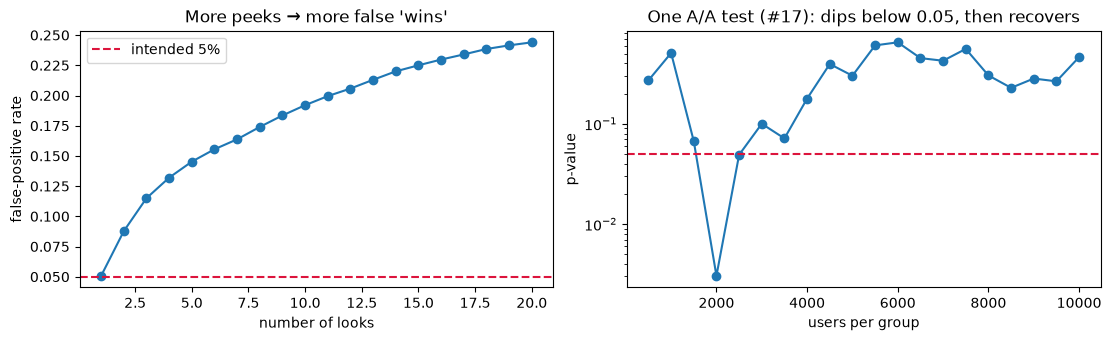

In [47]:
n_sims, looks, batch = 4_000, 20, 500
conv_a = rng.binomial(batch, 0.05, size=(n_sims, looks)).cumsum(axis=1)
conv_b = rng.binomial(batch, 0.05, size=(n_sims, looks)).cumsum(axis=1)
n_seen = batch * np.arange(1, looks + 1)                      # users per group at each look

pooled = (conv_a + conv_b) / (2 * n_seen)
z_stat = (conv_b - conv_a) / n_seen / np.sqrt(pooled * (1 - pooled) * 2 / n_seen)
p_at_look = 2 * stats.norm.sf(np.abs(z_stat))

fixed_horizon_fpr = (p_at_look[:, -1] < ALPHA).mean()
peeking_fpr = (p_at_look < ALPHA).any(axis=1).mean()
print(f"analyze once at the planned end : false-positive rate {fixed_horizon_fpr:.1%}")
print(f"stop at the first p < 0.05 (20 looks): false-positive rate {peeking_fpr:.1%}")

fpr_by_looks = [(p_at_look[:, :k] < ALPHA).any(axis=1).mean() for k in range(1, looks + 1)]
example = np.argmax((p_at_look < ALPHA).any(axis=1) & (p_at_look[:, -1] > 0.3))   # an A/A test that 'won' early but not at the end
fig, axes = plt.subplots(1, 2, figsize=(11, 3.3), layout="constrained")
axes[0].plot(range(1, looks + 1), fpr_by_looks, marker="o")
axes[0].axhline(ALPHA, color="crimson", ls="--", label="intended 5%")
axes[0].set(xlabel="number of looks", ylabel="false-positive rate", title="More peeks → more false 'wins'")
axes[0].legend()
axes[1].plot(n_seen, p_at_look[example], marker="o")
axes[1].axhline(ALPHA, color="crimson", ls="--")
axes[1].set(xlabel="users per group", ylabel="p-value", yscale="log", title=f"One A/A test (#{example}): dips below 0.05, then recovers")
plt.show()

**Fixes:** decide the sample size in advance and analyze once; or use methods designed for continuous monitoring — **sequential tests** (group-sequential boundaries such as O'Brien–Fleming, or *always-valid* p-values, used by several experimentation platforms).

### Statistical vs practical significance

With millions of users, even a trivial lift is "significant". *Controlled simulation:* 5,000,000 users per arm, a true lift of only +0.05 percentage points, and a business that needs at least **+0.2 points** to cover the cost of the change.

In [48]:
def ab_decision(ci_low, ci_high, practical_min):
    """Turn a CI for (treatment − control) into a decision. All inputs in the same units."""
    if ci_low > practical_min:
        return "SHIP ✅ — the whole CI is above the minimum worthwhile effect"
    if ci_high < 0:
        return "DON'T SHIP ❌ — treatment is significantly worse"
    if ci_low > 0 and ci_high < practical_min:
        return "DON'T SHIP — the effect is real but too small to matter"
    if ci_low > 0:
        return "LIKELY POSITIVE — real effect, but it may be below the worthwhile minimum; weigh cost or collect more data"
    if ci_high < practical_min:
        return "NO MEANINGFUL EFFECT — even the optimistic end of the CI is below the worthwhile minimum"
    return "INCONCLUSIVE — the CI includes both zero and worthwhile effects; the test was underpowered"


n_arm = 5_000_000
ctrl_conv, trt_conv = rng.binomial(n_arm, 0.0500), rng.binomial(n_arm, 0.0505)
z_big, p_big = proportions_ztest([trt_conv, ctrl_conv], [n_arm, n_arm])
low_big, high_big = confint_proportions_2indep(trt_conv, n_arm, ctrl_conv, n_arm, method="newcomb")
print(f"observed lift {trt_conv / n_arm - ctrl_conv / n_arm:+.4%} | p = {p_big:.2g} | 95% CI [{low_big:+.3%}, {high_big:+.3%}]")
print(f"statistically significant: {p_big < ALPHA}")
print("decision:", ab_decision(low_big, high_big, practical_min=0.002))

observed lift +0.0560% | p = 5.1e-05 | 95% CI [+0.029%, +0.083%]
statistically significant: True
decision: DON'T SHIP — the effect is real but too small to matter


> 💡 **Interview angle:** "The test is significant — do we ship?" — look at the **CI of the effect** vs the minimum worthwhile lift, check **guardrail** metrics and **SRM**, consider novelty effects and the cost of maintaining the change. "Significant" only means "probably not zero".

## 🔧 Build It From Scratch

Resampling methods are easy to code and a favourite "no libraries" interview task. We build three and **assert** they match scipy.

### 1) Permutation test for a difference in means

If H₀ ("the group label doesn't matter") is true, shuffling the labels shouldn't change the difference much. So: shuffle labels thousands of times, recompute the difference each time, and see how often a shuffled difference is at least as extreme as the real one.

In [49]:
def permutation_test_diff_means(a, b, n_resamples=20_000, rng=None):
    """Two-sided permutation test for mean(a) − mean(b). Returns (observed difference, p-value, null distribution)."""
    rng = np.random.default_rng(rng)
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    observed = a.mean() - b.mean()
    pooled = np.concatenate([a, b])
    shuffled = rng.permuted(np.tile(pooled, (n_resamples, 1)), axis=1)     # each row = one random relabelling
    null = shuffled[:, : len(a)].mean(axis=1) - shuffled[:, len(a):].mean(axis=1)
    tol = 1e-12 * max(1.0, abs(observed))                                  # so exact ties count as "at least as extreme"
    # +1 in numerator and denominator: the observed labelling is itself one of the possible labellings
    p_greater = (np.sum(null >= observed - tol) + 1) / (n_resamples + 1)
    p_less = (np.sum(null <= observed + tol) + 1) / (n_resamples + 1)
    # two-sided = 2 × the smaller one-sided p-value (scipy's convention; it also handles skewed null distributions)
    p_value = min(1.0, 2 * min(p_greater, p_less))
    return observed, p_value, null


def diff_in_means(x, y, axis):
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)


# (a) Sleep data treated as two independent groups: small enough for scipy to enumerate ALL 184,756 relabellings exactly
obs, p_ours, null_sleep = permutation_test_diff_means(drug2, drug1, rng=1)
p_exact = stats.permutation_test((drug2, drug1), diff_in_means, n_resamples=np.inf, vectorized=True).pvalue
print(f"sleep : ours p = {p_ours:.4f} | scipy exact p = {p_exact:.4f} | Welch t-test p = {stats.ttest_ind(drug2, drug1, equal_var=False).pvalue:.4f}")
assert abs(p_ours - p_exact) < 0.01

# (b) Dinner vs lunch bills (244 rows): too many relabellings to enumerate, so both sides sample random permutations.
#     Random sampling adds Monte-Carlo noise, so we compare within 3 Monte-Carlo standard errors.
obs, p_ours_tips, _ = permutation_test_diff_means(dinner, lunch, n_resamples=20_000, rng=2)
p_scipy_tips = stats.permutation_test((dinner, lunch), diff_in_means, n_resamples=100_000, batch=20_000, vectorized=True, rng=3).pvalue
mc_se = np.sqrt(2 * p_scipy_tips * (1 - p_scipy_tips / 2) / 20_000 + 2 * p_scipy_tips * (1 - p_scipy_tips / 2) / 100_000)
print(f"tips  : ours p = {p_ours_tips:.4f} (20k shuffles) | scipy p = {p_scipy_tips:.4f} (100k shuffles) | "
      f"Monte-Carlo SE of the gap ≈ {mc_se:.4f} | observed difference ${obs:.2f}")
assert abs(p_ours_tips - p_scipy_tips) < 3 * mc_se
print("permutation test matches scipy ✅")

sleep : ours p = 0.0806 | scipy exact p = 0.0814 | Welch t-test p = 0.0794


tips  : ours p = 0.0033 (20k shuffles) | scipy p = 0.0028 (100k shuffles) | Monte-Carlo SE of the gap ≈ 0.0006 | observed difference $3.63
permutation test matches scipy ✅


### 2) Percentile bootstrap confidence interval

In [50]:
def bootstrap_percentile_ci(data, statistic, n_resamples=10_000, confidence=0.95, rng=None):
    """Percentile bootstrap CI. `statistic` must accept an `axis` argument (np.mean, np.median, …)."""
    rng = np.random.default_rng(rng)
    data = np.asarray(data)
    idx = rng.integers(0, len(data), size=(n_resamples, len(data)))       # resample row positions WITH replacement
    boot_stats = statistic(data[idx], axis=1)
    tail = (1 - confidence) / 2
    low, high = np.quantile(boot_stats, [tail, 1 - tail])
    return low, high, boot_stats.std(ddof=1)


for label, data, statistic in [("mean tip %", tip_pct, np.mean), ("median bill", bills.to_numpy(), np.median)]:
    low, high, boot_se = bootstrap_percentile_ci(data, statistic, rng=4)
    ref = stats.bootstrap((data,), statistic, n_resamples=10_000, method="percentile", rng=5)
    ref_ci = ref.confidence_interval
    print(f"{label:>11}: ours [{low:.4f}, {high:.4f}] | scipy [{ref_ci.low:.4f}, {ref_ci.high:.4f}] | SE ours {boot_se:.4f} vs scipy {ref.standard_error:.4f}")
    assert np.allclose([low, high], [ref_ci.low, ref_ci.high], atol=0.25 * boot_se)
print("bootstrap CI matches scipy within Monte-Carlo noise ✅")

 mean tip %: ours [0.1536, 0.1688] | scipy [0.1534, 0.1689] | SE ours 0.0039 vs scipy 0.0039
median bill: ours [16.5350, 18.6650] | scipy [16.5350, 18.6650] | SE ours 0.5178 vs scipy 0.5232
bootstrap CI matches scipy within Monte-Carlo noise ✅


### 3) Welch's t-test from the formula

$t = \dfrac{\bar a - \bar b}{\sqrt{s_a^2/n_a + s_b^2/n_b}}$, with Welch–Satterthwaite degrees of freedom $\nu = \dfrac{(s_a^2/n_a + s_b^2/n_b)^2}{\frac{(s_a^2/n_a)^2}{n_a-1} + \frac{(s_b^2/n_b)^2}{n_b-1}}$

In [51]:
def welch_t_test(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    va, vb = a.var(ddof=1) / len(a), b.var(ddof=1) / len(b)
    t = (a.mean() - b.mean()) / np.sqrt(va + vb)
    df = (va + vb) ** 2 / (va ** 2 / (len(a) - 1) + vb ** 2 / (len(b) - 1))
    p = 2 * stats.t.sf(abs(t), df)
    return t, df, p


ours = welch_t_test(dinner, lunch)
ref = stats.ttest_ind(dinner, lunch, equal_var=False)
print(f"ours : t = {ours[0]:.6f}, df = {ours[1]:.3f}, p = {ours[2]:.6f}")
print(f"scipy: t = {ref.statistic:.6f}, df = {ref.df:.3f}, p = {ref.pvalue:.6f}")
assert np.allclose(ours, (ref.statistic, ref.df, ref.pvalue))
print("Welch t-test matches scipy exactly ✅")

ours : t = 3.122986, df = 143.293, p = 0.002167
scipy: t = 3.122986, df = 143.293, p = 0.002167
Welch t-test matches scipy exactly ✅


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Printing a conclusion that ignores the test result

A real bug in many tutorials: the test runs, then a hard-coded success message is printed no matter what. *Controlled data where the training has **no** real effect.*

In [52]:
scores_before = rng.normal(70, 10, size=25)
scores_after = scores_before + rng.normal(0, 5, size=25)      # no true improvement
training_test = stats.ttest_rel(scores_after, scores_before)
print(f"p = {training_test.pvalue:.3f}")
print("❌ Training significantly improved scores!")               # printed regardless of p

diff_ci = training_test.confidence_interval()
if training_test.pvalue < ALPHA and diff_ci.low > 0:
    print(f"✅ Scores improved significantly (mean change 95% CI [{diff_ci.low:.2f}, {diff_ci.high:.2f}])")
elif training_test.pvalue < ALPHA:
    print(f"✅ Scores got significantly WORSE (95% CI [{diff_ci.low:.2f}, {diff_ci.high:.2f}])")
else:
    print(f"✅ No evidence of a change (p = {training_test.pvalue:.3f}; mean change 95% CI [{diff_ci.low:.2f}, {diff_ci.high:.2f}])")

p = 0.069
❌ Training significantly improved scores!
✅ No evidence of a change (p = 0.069; mean change 95% CI [-0.16, 3.93])


### ❌ Pitfall 2 — "Shapiro–Wilk p > 0.05, so the data are normal"

A normality test can only *fail to find* non-normality. Small samples pass even when clearly skewed; huge samples fail over tiny, harmless deviations.

❌ exponential data (strongly skewed), n = 10: Shapiro 'looks normal' (p > 0.05) in 55% of samples
❌ t-distribution with 10 df (nearly normal), n = 4,000: Shapiro rejects normality in 100% of samples


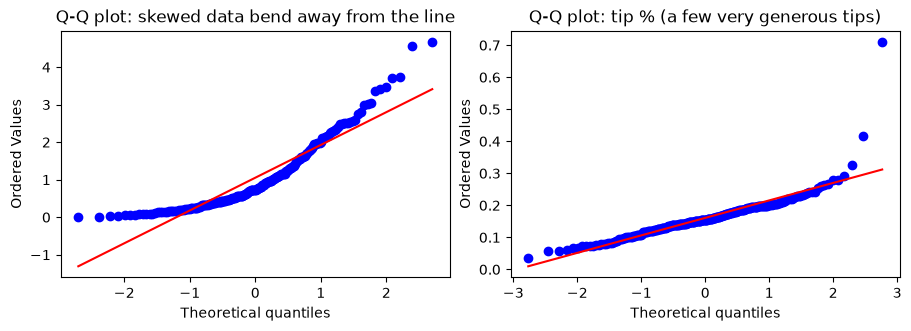

✅ With moderate n, rely on the CLT (Welch t-test) — or use bootstrap / permutation / Mann–Whitney for small or heavy-tailed samples.


In [53]:
small_skewed_pass = np.mean([stats.shapiro(stats.expon.rvs(size=10, random_state=rng)).pvalue > ALPHA for _ in range(1_000)])
large_nearly_normal_fail = np.mean([stats.shapiro(stats.t.rvs(df=10, size=4_000, random_state=rng)).pvalue < ALPHA for _ in range(100)])
print(f"❌ exponential data (strongly skewed), n = 10: Shapiro 'looks normal' (p > 0.05) in {small_skewed_pass:.0%} of samples")
print(f"❌ t-distribution with 10 df (nearly normal), n = 4,000: Shapiro rejects normality in {large_nearly_normal_fail:.0%} of samples")

# ✅ Look at the data (a Q-Q plot), think about the process, and use methods that don't need normality when in doubt
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), layout="constrained")
stats.probplot(stats.expon.rvs(size=200, random_state=rng), dist="norm", plot=axes[0])
axes[0].set_title("Q-Q plot: skewed data bend away from the line")
stats.probplot(tips["tip_pct"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot: tip % (a few very generous tips)")
plt.show()
print("✅ With moderate n, rely on the CLT (Welch t-test) — or use bootstrap / permutation / Mann–Whitney for small or heavy-tailed samples.")

### ❌ Pitfall 3 — Independent test on paired data

In [54]:
print(f"❌ ttest_ind on the sleep data: p = {stats.ttest_ind(drug2, drug1, equal_var=False).pvalue:.4f}  (ignores that it's the same patients)")
print(f"✅ ttest_rel on the sleep data: p = {stats.ttest_rel(drug2, drug1).pvalue:.4f}")

❌ ttest_ind on the sleep data: p = 0.0794  (ignores that it's the same patients)
✅ ttest_rel on the sleep data: p = 0.0028


### ❌ Pitfall 4 — Mixing up `ddof` between NumPy and pandas

In [55]:
latencies = np.array([120, 135, 118, 160, 142])
print(f"❌ np.std(x)             = {np.std(latencies):.3f}   (ddof=0: population formula)")
print(f"   pd.Series(x).std()    = {pd.Series(latencies).std():.3f}   (ddof=1: sample formula)")
print(f"✅ np.std(x, ddof=1)     = {np.std(latencies, ddof=1):.3f}   → be explicit when estimating from a sample")

❌ np.std(x)             = 15.414   (ddof=0: population formula)
   pd.Series(x).std()    = 17.234   (ddof=1: sample formula)
✅ np.std(x, ddof=1)     = 17.234   → be explicit when estimating from a sample


### ❌ Pitfall 5 — Reading "not significant" as "no effect"

In [56]:
n_tiny = 15
small_a = rng.normal(0.0, 1, size=(2_000, n_tiny))
small_b = rng.normal(0.5, 1, size=(2_000, n_tiny))             # a REAL medium effect in every study
small_res = stats.ttest_ind(small_b, small_a, axis=1, equal_var=False)
print(f"❌ {np.mean(small_res.pvalue >= ALPHA):.0%} of these studies conclude 'no effect', although d = 0.5 is real "
      f"(power with n = {n_tiny}: {TTestIndPower().power(effect_size=0.5, nobs1=n_tiny, alpha=ALPHA):.0%})")

study = stats.ttest_ind(small_b[0], small_a[0], equal_var=False)
ci_study = study.confidence_interval()
print(f"✅ Report the CI instead: study #1 difference = {small_b[0].mean() - small_a[0].mean():.2f}, "
      f"95% CI [{ci_study.low:.2f}, {ci_study.high:.2f}], p = {study.pvalue:.3f} — say what effects the data can and cannot rule out.")

❌ 76% of these studies conclude 'no effect', although d = 0.5 is real (power with n = 15: 26%)
✅ Report the CI instead: study #1 difference = 0.36, 95% CI [-0.26, 0.97], p = 0.245 — say what effects the data can and cannot rule out.


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Normal tail probability
IQ scores follow roughly a Normal(100, 15). What fraction of people score **above 130**? Store it in `p_above_130`.

In [57]:
p_above_130 = None  # TODO
check("p_above_130", p_above_130, 0.0227501, hint="stats.norm(loc=100, scale=15).sf(130)")

⏳ p_above_130: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
p_above_130 = stats.norm(loc=100, scale=15).sf(130)
check("p_above_130", p_above_130, 0.0227501)
```
130 is exactly 2 standard deviations above the mean, and about 2.3% of a normal distribution lies beyond +2σ.
</details>

### 🟢 Exercise 2 — At least 8 heads
What is the probability of getting **at least 8 heads** in 10 fair coin flips? Store it in `p_8_or_more`.

In [58]:
p_8_or_more = None  # TODO
check("p_8_or_more", p_8_or_more, 0.0546875, hint="'At least 8' = P(X > 7) = stats.binom(n=10, p=0.5).sf(7).")

⏳ p_8_or_more: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
p_8_or_more = stats.binom(n=10, p=0.5).sf(7)
check("p_8_or_more", p_8_or_more, 0.0546875)
```
By hand: (C(10,8) + C(10,9) + C(10,10)) / 2¹⁰ = (45 + 10 + 1) / 1024 = 56/1024.
</details>

### 🟢 Exercise 3 — Standard error of the mean
Compute the **standard error of the mean** of `response_ms` (use the sample standard deviation). Store it in `sem_ms`.

In [59]:
response_ms = np.array([120, 135, 118, 160, 142, 128, 150, 138])
sem_ms = None  # TODO
check("sem_ms", sem_ms, 5.0988006, hint="std(ddof=1) / sqrt(n), or stats.sem(response_ms).")

⏳ sem_ms: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
response_ms = np.array([120, 135, 118, 160, 142, 128, 150, 138])
sem_ms = response_ms.std(ddof=1) / np.sqrt(len(response_ms))
check("sem_ms", sem_ms, 5.0988006)
check("sem_ms (scipy)", stats.sem(response_ms), 5.0988006)
```
</details>

### 🟡 Exercise 4 — Two positive tests in a row
Using the medical test from Section 3 (prevalence 1%, sensitivity 90%, specificity 91%), a patient tests positive **twice** (assume the two test results are independent given disease status). What is P(sick | two positives)? Store it in `p_after_two_positives`.

In [60]:
p_after_two_positives = None  # TODO
check("p_after_two_positives", p_after_two_positives, 0.5025126,
      hint="Yesterday's posterior is today's prior: posterior(posterior(0.01, 0.9, 0.91), 0.9, 0.91).")

⏳ p_after_two_positives: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
after_first = posterior(0.01, 0.90, 0.91)
p_after_two_positives = posterior(after_first, 0.90, 0.91)
check("p_after_two_positives", p_after_two_positives, 0.5025126)

# Same answer in one step: P(++ | sick) = 0.9², P(++ | healthy) = 0.09²
one_step = 0.9**2 * 0.01 / (0.9**2 * 0.01 + 0.09**2 * 0.99)
check("one-step Bayes", one_step, 0.5025126)
```
Even two positives only get you to about 50% — the rare-disease prior is powerful.
</details>

### 🟡 Exercise 5 — Benjamini–Hochberg by hand
Without statsmodels or scipy's corrections, return a boolean array `bh_reject` (same order as `p_list`) marking which hypotheses BH rejects at q = 0.05.

In [61]:
p_list = np.array([0.04, 0.5, 0.012, 0.03, 0.02])
bh_reject = None  # TODO
check("bh_reject", bh_reject, np.array([True, False, True, True, True]),
      hint="Sort p; compare p_(k) with k/m·q; find the LARGEST k that passes; reject everything up to it (even ones that failed individually).")

⏳ bh_reject: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
p_list = np.array([0.04, 0.5, 0.012, 0.03, 0.02])
q = 0.05
m = len(p_list)
order = np.argsort(p_list)
thresholds = q * np.arange(1, m + 1) / m
passes = p_list[order] <= thresholds
k = np.max(np.nonzero(passes)[0]) + 1 if passes.any() else 0   # largest rank that passes
bh_reject = np.zeros(m, dtype=bool)
bh_reject[order[:k]] = True
check("bh_reject", bh_reject, np.array([True, False, True, True, True]))
check("bh_reject (statsmodels)", multipletests(p_list, alpha=q, method="fdr_bh")[0], np.array([True, False, True, True, True]))
```
The smallest p-value (0.012) is *above* its own threshold (0.01), but BH is a **step-up** procedure: because 0.04 ≤ 4/5·0.05, all four smallest are rejected. Bonferroni (0.05/5 = 0.01) would reject none.
</details>

### 🔴 Exercise 6 — Two-proportion z-test from scratch (interview classic)
Implement `two_proportion_ztest(x1, n1, x2, n2)` returning `(z, two_sided_p)` using the **pooled** proportion under H₀. Then test: treatment 250 conversions / 4,000 users vs control 200 / 4,000.

In [62]:
def two_proportion_ztest(x1, n1, x2, n2):
    # TODO: p1, p2 → pooled proportion → standard error → z → two-sided p-value
    return None


check("two_proportion_ztest", two_proportion_ztest(250, 4000, 200, 4000), [2.4262484, 0.0152558],
      hint="p_pool = (x1 + x2) / (n1 + n2); se = sqrt(p_pool (1 − p_pool) (1/n1 + 1/n2)); z = (p1 − p2) / se; p = 2·norm.sf(|z|).")

⏳ two_proportion_ztest: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def two_proportion_ztest(x1, n1, x2, n2):
    p1, p2 = x1 / n1, x2 / n2
    p_pool = (x1 + x2) / (n1 + n2)                     # under H0 both groups share one rate
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    z = (p1 - p2) / se
    return z, 2 * stats.norm.sf(abs(z))


check("two_proportion_ztest", two_proportion_ztest(250, 4000, 200, 4000), [2.4262484, 0.0152558])
check("matches statsmodels", two_proportion_ztest(250, 4000, 200, 4000), proportions_ztest([250, 200], [4000, 4000]))
```
Talk through it in an interview: pooled SE for the *test* (H₀ says the rates are equal), unpooled SE for the *confidence interval* of the difference.
</details>

## 🚀 Mini Project: Did the E-Mail Campaign Work?

**Data:** Kevin Hillstrom's **MineThatData E-Mail Analytics challenge** — a real randomized experiment. **64,000 customers** who had bought in the last 12 months were randomly split into three equal groups: a **Men's merchandise e-mail**, a **Women's merchandise e-mail**, or **no e-mail** (control). Visits, purchases (`conversion`), and dollars spent (`spend`) were tracked for the following two weeks.

**Goal:** analyze it the way an experimentation team would — sanity checks → plan → primary test → secondary metrics → multiple-testing correction → a decision based on practical significance.

**Steps:** load → randomization checks → what the design could detect → conversion → spend → correct for multiple tests → decide.

### Step 1 — Load and inspect

In [63]:
hillstrom = load_csv("http://www.minethatdata.com/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv",
                     "hillstrom_email.csv")
print(hillstrom.shape)
print(hillstrom.head())
arm_summary = hillstrom.groupby("segment").agg(
    customers=("conversion", "size"), visit_rate=("visit", "mean"),
    conversion_rate=("conversion", "mean"), spend_per_customer=("spend", "mean"))
arm_summary.round(4)

(64000, 12)
   recency history_segment  history  mens  womens   zip_code  newbie channel  \
0       10  2) $100 - $200   142.44     1       0  Surburban       0   Phone   
1        6  3) $200 - $350   329.08     1       1      Rural       1     Web   
2        7  2) $100 - $200   180.65     0       1  Surburban       1     Web   
3        9  5) $500 - $750   675.83     1       0      Rural       1     Web   
4        2    1) $0 - $100    45.34     1       0      Urban       0     Web   

         segment  visit  conversion  spend  
0  Womens E-Mail      0           0    0.0  
1      No E-Mail      0           0    0.0  
2  Womens E-Mail      0           0    0.0  
3    Mens E-Mail      0           0    0.0  
4  Womens E-Mail      0           0    0.0  


,customers,visit_rate,conversion_rate,spend_per_customer
segment,,,,
Mens E-Mail,21307,0.1828,0.0125,1.4226
No E-Mail,21306,0.1062,0.0057,0.6528
Womens E-Mail,21387,0.1514,0.0088,1.0772


### Step 2 — Sanity checks: was randomization healthy?

1. **Sample ratio mismatch (SRM):** the design was equal thirds, so group sizes should be consistent with 1:1:1. A tiny p-value here means a broken assignment or logging pipeline — stop and debug before reading any results.
2. **Covariate balance:** pre-experiment attributes should look the same in every arm. We use the **standardized mean difference (SMD)**; |SMD| < 0.1 is the usual "balanced" rule.

In [64]:
arm_sizes = hillstrom["segment"].value_counts().sort_index()
srm = stats.chisquare(arm_sizes.to_numpy())                     # expected: equal counts
print(arm_sizes.to_string())
print(f"SRM chi-square p = {srm.pvalue:.3f} → {'⚠️ sample ratio mismatch — investigate!' if srm.pvalue < 0.001 else 'no evidence of sample ratio mismatch'}")

CONTROL = "No E-Mail"
TREATMENTS = ["Mens E-Mail", "Womens E-Mail"]
control_df = hillstrom[hillstrom["segment"] == CONTROL]
covariates = ["recency", "history", "mens", "womens", "newbie"]
balance_rows = []
for arm in TREATMENTS:
    arm_df = hillstrom[hillstrom["segment"] == arm]
    for col in covariates:
        pooled_sd = np.sqrt((arm_df[col].var() + control_df[col].var()) / 2)
        balance_rows.append({"arm": arm, "covariate": col, "SMD vs control": (arm_df[col].mean() - control_df[col].mean()) / pooled_sd})
balance = pd.DataFrame(balance_rows)
max_smd = balance["SMD vs control"].abs().max()
print(balance.pivot(index="covariate", columns="arm", values="SMD vs control").round(4))
print(f"largest |SMD| = {max_smd:.4f} → {'covariates balanced ✅' if max_smd < 0.1 else '⚠️ imbalance'}")

segment
Mens E-Mail      21307
No E-Mail        21306
Womens E-Mail    21387
SRM chi-square p = 0.904 → no evidence of sample ratio mismatch
arm        Mens E-Mail  Womens E-Mail
covariate                            
history         0.0076         0.0065
mens           -0.0046        -0.0086
newbie         -0.0009         0.0026
recency         0.0068         0.0052
womens          0.0076         0.0049
largest |SMD| = 0.0086 → covariates balanced ✅


### Step 3 — What could this design detect?

In a real project the power analysis happens *before* launch. Here the sample is fixed, so we ask the equivalent question: with ~21,300 customers per arm, what is the **minimum detectable effect** on conversion at 80% power?

In [65]:
n_control = len(control_df)
base_conv = control_df["conversion"].mean()
h_detectable = NormalIndPower().solve_power(effect_size=None, nobs1=n_control, alpha=ALPHA, power=0.80, ratio=1.0)
detectable_rate = np.sin(np.arcsin(np.sqrt(base_conv)) + h_detectable / 2) ** 2       # invert Cohen's h
mde_points = detectable_rate - base_conv
print(f"control conversion = {base_conv:.3%} with {n_control:,} customers")
print(f"minimum detectable lift at 80% power: +{mde_points:.3%} points (conversion {base_conv:.3%} → {detectable_rate:.3%}, relative +{mde_points / base_conv:.0%})")

control conversion = 0.573% with 21,306 customers
minimum detectable lift at 80% power: +0.223% points (conversion 0.573% → 0.796%, relative +39%)


### Step 4 — Primary metric: conversion

Two-proportion z-test plus a **Newcombe confidence interval** for the difference in conversion rates, for each e-mail against control.

In [66]:
def compare_rates(treat_df, control_df, metric):
    x_t, n_t = int(treat_df[metric].sum()), len(treat_df)
    x_c, n_c = int(control_df[metric].sum()), len(control_df)
    _, p_value = proportions_ztest([x_t, x_c], [n_t, n_c])
    low, high = confint_proportions_2indep(x_t, n_t, x_c, n_c, method="newcomb")
    rate_t, rate_c = x_t / n_t, x_c / n_c
    return {"metric": metric, "treatment rate": rate_t, "control rate": rate_c, "difference": rate_t - rate_c,
            "CI low": low, "CI high": high, "relative lift": rate_t / rate_c - 1, "p-value": p_value}


results = []
for arm in TREATMENTS:
    arm_df = hillstrom[hillstrom["segment"] == arm]
    for metric in ("conversion", "visit"):
        results.append({"arm": arm, **compare_rates(arm_df, control_df, metric)})
rate_results = pd.DataFrame(results)
rate_results.round(5)

,arm,metric,treatment rate,control rate,difference,CI low,CI high,relative lift,p-value
0,Mens E-Mail,conversion,0.01253,0.00573,0.00681,0.00501,0.00864,1.18842,0.00000
1,Mens E-Mail,visit,0.18276,0.10617,0.07659,0.06995,0.08323,0.72140,0.00000
2,Womens E-Mail,conversion,0.00884,0.00573,0.00311,0.00150,0.00475,0.54331,0.00016
3,Womens E-Mail,visit,0.15140,0.10617,0.04523,0.03889,0.05157,0.42606,0.00000


### Step 5 — Secondary metric: spend per customer

Spend is **zero-inflated and heavy-tailed** — most customers buy nothing. With ~21,000 customers per arm, Welch's t-test on the mean is reasonable by the CLT; we confirm with a **bootstrap CI** that makes no normality assumption.

In [67]:
share_buyers = (hillstrom["spend"] > 0).mean()
print(f"customers with any spend: {share_buyers:.2%} | spend among buyers: median ${hillstrom.loc[hillstrom.spend > 0, 'spend'].median():.2f}, max ${hillstrom['spend'].max():.2f}")

spend_rows = []
for arm in TREATMENTS:
    treat_spend = hillstrom.loc[hillstrom["segment"] == arm, "spend"].to_numpy()
    ctrl_spend = control_df["spend"].to_numpy()
    welch = stats.ttest_ind(treat_spend, ctrl_spend, equal_var=False)
    boot = stats.bootstrap((treat_spend, ctrl_spend), diff_in_means, n_resamples=2_000, batch=100,
                           method="percentile", rng=rng)
    spend_rows.append({"arm": arm, "metric": "spend", "treatment mean": treat_spend.mean(), "control mean": ctrl_spend.mean(),
                       "difference": treat_spend.mean() - ctrl_spend.mean(),
                       "Welch CI low": welch.confidence_interval().low, "Welch CI high": welch.confidence_interval().high,
                       "bootstrap CI low": boot.confidence_interval.low, "bootstrap CI high": boot.confidence_interval.high,
                       "p-value": welch.pvalue})
spend_results = pd.DataFrame(spend_rows)
spend_results.round(4)

customers with any spend: 0.90% | spend among buyers: median $80.80, max $499.00


,arm,metric,treatment mean,control mean,difference,Welch CI low,Welch CI high,bootstrap CI low,bootstrap CI high,p-value
0,Mens E-Mail,spend,1.4226,0.6528,0.7698,0.4851,1.0545,0.4846,1.0475,0.0000
1,Womens E-Mail,spend,1.0772,0.6528,0.4244,0.1690,0.6799,0.1636,0.6862,0.0011


### Step 6 — Correct for multiple comparisons

We made **6** comparisons (2 e-mails × 3 metrics). We apply **Holm** (controls the chance of *any* false claim) because each claim here drives a business decision.

In [68]:
all_tests = pd.concat([rate_results[["arm", "metric", "p-value"]], spend_results[["arm", "metric", "p-value"]]], ignore_index=True)
all_tests["significant (raw)"] = all_tests["p-value"] < ALPHA
all_tests["significant (Holm)"], all_tests["Holm-adjusted p"], _, _ = multipletests(all_tests["p-value"], alpha=ALPHA, method="holm")
print(all_tests.to_string(index=False))
print(f"\n{all_tests['significant (Holm)'].sum()} of {len(all_tests)} comparisons remain significant after Holm correction")

          arm     metric       p-value  significant (raw)  significant (Holm)  Holm-adjusted p
  Mens E-Mail conversion  1.523224e-13               True                True     6.092894e-13
  Mens E-Mail      visit 5.685165e-112               True                True    3.411099e-111
Womens E-Mail conversion  1.571051e-04               True                True     3.142103e-04
Womens E-Mail      visit  3.182403e-44               True                True     1.591202e-43
  Mens E-Mail      spend  1.163815e-07               True                True     3.491445e-07
Womens E-Mail      spend  1.129397e-03               True                True     1.129397e-03

6 of 6 comparisons remain significant after Holm correction


### Step 7 — Decide: practical significance and which e-mail wins

Statistical significance says "probably not zero". The business question is "is it worth it?". We state an **explicit assumption** — a conversion lift of at least **+0.25 percentage points** is needed to justify a campaign — and let the confidence intervals decide. We also compare the two e-mails head to head.

In [69]:
MIN_WORTHWHILE_LIFT = 0.0025      # business assumption: +0.25 percentage points of conversion

conversion_rows = rate_results[rate_results["metric"] == "conversion"].set_index("arm")
for arm in TREATMENTS:
    row = conversion_rows.loc[arm]
    holm_sig = bool(all_tests.query("arm == @arm and metric == 'conversion'")["significant (Holm)"].iloc[0])
    print(f"{arm}: lift {row['difference']:+.3%} (95% CI [{row['CI low']:+.3%}, {row['CI high']:+.3%}]), "
          f"relative {row['relative lift']:+.0%}, significant after Holm: {holm_sig}")
    print(f"   decision: {ab_decision(row['CI low'], row['CI high'], MIN_WORTHWHILE_LIFT)}")

    spend_row = spend_results.set_index("arm").loc[arm]
    print(f"   extra spend per 1,000 e-mails: ${1000 * spend_row['difference']:,.0f} "
          f"(bootstrap 95% CI ${1000 * spend_row['bootstrap CI low']:,.0f} – ${1000 * spend_row['bootstrap CI high']:,.0f})")

mens_df = hillstrom[hillstrom["segment"] == "Mens E-Mail"]
womens_df = hillstrom[hillstrom["segment"] == "Womens E-Mail"]
head_to_head = compare_rates(mens_df, womens_df, "conversion")
winner = "Mens E-Mail" if head_to_head["difference"] > 0 else "Womens E-Mail"
print(f"\nHead to head (Mens − Womens) conversion: {head_to_head['difference']:+.3%} "
      f"(95% CI [{head_to_head['CI low']:+.3%}, {head_to_head['CI high']:+.3%}], p = {head_to_head['p-value']:.4f})")
if head_to_head["p-value"] < ALPHA:
    print(f"→ {winner} converts significantly better than the other e-mail.")
else:
    print("→ No significant difference between the two e-mails; choose on cost or other metrics.")

Mens E-Mail: lift +0.681% (95% CI [+0.501%, +0.864%]), relative +119%, significant after Holm: True
   decision: SHIP ✅ — the whole CI is above the minimum worthwhile effect
   extra spend per 1,000 e-mails: $770 (bootstrap 95% CI $485 – $1,047)
Womens E-Mail: lift +0.311% (95% CI [+0.150%, +0.475%]), relative +54%, significant after Holm: True
   decision: LIKELY POSITIVE — real effect, but it may be below the worthwhile minimum; weigh cost or collect more data
   extra spend per 1,000 e-mails: $424 (bootstrap 95% CI $164 – $686)

Head to head (Mens − Womens) conversion: +0.369% (95% CI [+0.175%, +0.566%], p = 0.0002)
→ Mens E-Mail converts significantly better than the other e-mail.


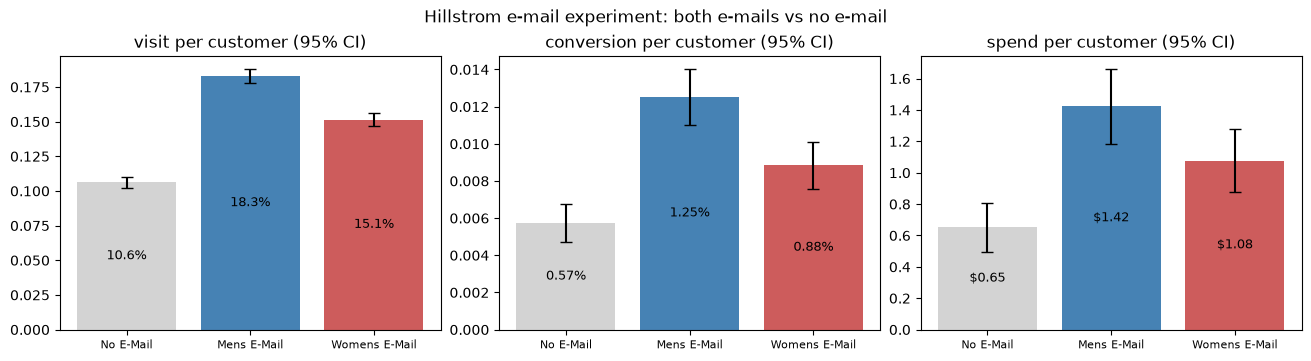

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), layout="constrained")
arms = [CONTROL, *TREATMENTS]
for ax, metric, fmt in zip(axes, ["visit", "conversion", "spend"], ["{:.1%}", "{:.2%}", "${:.2f}"]):
    means_by_arm, err_by_arm = [], []
    for arm in arms:
        values = hillstrom.loc[hillstrom["segment"] == arm, metric]
        means_by_arm.append(values.mean())
        err_by_arm.append(stats.t.ppf(0.975, len(values) - 1) * values.std(ddof=1) / np.sqrt(len(values)))
    bars = ax.bar(arms, means_by_arm, yerr=err_by_arm, capsize=4, color=["lightgray", "steelblue", "indianred"])
    ax.bar_label(bars, labels=[fmt.format(v) for v in means_by_arm], label_type="center", fontsize=9, color="black")
    ax.set_title(f"{metric} per customer (95% CI)")
    ax.tick_params(axis="x", labelsize=8)
fig.suptitle("Hillstrom e-mail experiment: both e-mails vs no e-mail")
plt.show()

**Stretch goals**
1. **Heterogeneous effects:** does the Women's e-mail work better for customers who previously bought women's merchandise (`womens == 1`)? Test within each subgroup — and remember to correct for the extra tests.
2. **CUPED-style variance reduction:** regress spend on pre-experiment `history` and analyze the residuals. How much narrower does the CI get?
3. **Sequential analysis:** pretend the data arrived in 10 equal daily batches and apply an O'Brien–Fleming-style boundary instead of a fixed 0.05 at each look.
4. Replace the Welch test on spend with a test on **winsorized** spend (cap at the 99.9th percentile) and compare conclusions.

### 🗣️ How to talk about this in an interview
- "I analyzed a real three-arm randomized e-mail experiment with 64,000 customers: first **sanity checks** — a chi-square SRM test on the arm sizes and standardized mean differences on pre-experiment covariates."
- "I computed the **minimum detectable effect** for the fixed sample, so I knew what size of lift the test could reliably find."
- "For conversion I used a two-proportion z-test with a Newcombe CI; for zero-inflated spend I used Welch's t-test and confirmed with a **bootstrap CI**."
- "I made six comparisons, so I applied **Holm's correction**, and I based the ship decision on whether the **confidence interval** cleared an explicit minimum worthwhile lift — not just on p < 0.05."
- "Next I'd look at heterogeneous treatment effects by customer history (uplift modeling) and use CUPED to cut variance."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What is a p-value? What is it *not*?**

<details><summary>Show answer</summary>

- **30-second answer:** The probability of seeing data at least as extreme as ours **if the null hypothesis were true**. Small p means the data would be surprising under H₀.
- **Go deeper:** It is P(data | H₀), not P(H₀ | data) — getting the latter needs a prior (Bayes). When few tested ideas are real, a large share of p < 0.05 results are false positives. p also shrinks with sample size, so always report an **effect size and confidence interval**. The American Statistical Association's 2016 statement makes exactly these points.
- **❌ Common wrong answer:** "The probability that the null hypothesis is true" or "the probability the result happened by chance".

</details>

**Q2. Explain Type I and Type II errors and power. Which is worse?**

<details><summary>Show answer</summary>

- **30-second answer:** Type I = false positive (rejecting a true H₀), controlled by α. Type II = false negative (missing a real effect), rate β. **Power = 1 − β**, usually targeted at 80%.
- **Go deeper:** For a fixed sample, lowering α raises β. Which is worse depends on costs: shipping a harmful change or approving an ineffective drug (Type I) vs. missing a cancer in screening or abandoning a good feature (Type II). You buy both down with more data or less noise.
- **❌ Common wrong answer:** "α is the probability that our conclusion is wrong." (It's the false-positive rate *when H₀ is true*.)

</details>

**Q3. State the Central Limit Theorem. Why does it matter for A/B testing?**

<details><summary>Show answer</summary>

- **30-second answer:** For independent samples from a distribution with finite variance, the sample mean is approximately normal with mean μ and standard error σ/√n as n grows — whatever the original shape.
- **Go deeper:** Conversion rate and revenue per user are means, so z/t-tests and CIs work at A/B-test sample sizes. Convergence is slower for skewed, heavy-tailed metrics (revenue with "whales") — use bigger samples, winsorizing, or the bootstrap. It fails for infinite-variance distributions like the Cauchy.
- **❌ Common wrong answer:** "With enough data, the data itself becomes normally distributed."

</details>

**Q4. How do you interpret a 95% confidence interval?**

<details><summary>Show answer</summary>

- **30-second answer:** It comes from a procedure that, over many repeated samples, captures the true parameter 95% of the time. Any single interval either contains the truth or not.
- **Go deeper:** A Bayesian **credible interval** is what supports "95% probability the parameter is in here" (given a prior). A 95% CI for a difference that excludes 0 corresponds to rejecting H₀ at α = 0.05 (for matching test/interval methods). Width shrinks like 1/√n.
- **❌ Common wrong answer:** "There is a 95% probability the true mean is in this interval" or "95% of the data lie in this interval".

</details>

**Q5. A test for a disease with 1% prevalence has 90% sensitivity and 91% specificity. You test positive. What's the probability you have the disease?**

<details><summary>Show answer</summary>

- **30-second answer:** About **9%**. Out of 100,000 people: 1,000 are sick and 900 test positive; 99,000 are healthy and 8,910 test positive. 900 / 9,810 ≈ 9.2%.
- **Go deeper:** This is the base-rate fallacy. In ML it's why precision collapses for rare classes (fraud, disease) even with high accuracy — precision is exactly P(positive class | flagged). A second independent positive test raises it to about 50%.
- **❌ Common wrong answer:** "90%" (confusing P(+ | sick) with P(sick | +)).

</details>

**Q6. What is Simpson's paradox, and how do you avoid being fooled by it?**

<details><summary>Show answer</summary>

- **30-second answer:** A trend in aggregated data reverses within subgroups because a **confounder** drives both variables — e.g. UC Berkeley admissions favoured men overall, but most departments admitted women at similar or higher rates; women applied more to competitive departments.
- **Go deeper:** Randomized experiments remove confounding by design. In observational data, reason with a causal diagram about which variables to adjust for. Don't blindly stratify on everything: adjusting for a **mediator** or a **collider** can create bias.
- **❌ Common wrong answer:** "Always use the most granular breakdown" — the right level depends on the causal question.

</details>

**Q7. Bonferroni vs Benjamini–Hochberg — what does each control and when would you use it?**

<details><summary>Show answer</summary>

- **30-second answer:** Bonferroni (and the more powerful Holm) control the **family-wise error rate** — the chance of *any* false positive. BH controls the **false discovery rate** — the expected share of false positives among the things you call significant.
- **Go deeper:** Use FWER control when any single false claim is costly (a small set of primary endpoints). Use BH for screening many hypotheses (hundreds of metrics, genes, feature tests) where a few false leads are acceptable. BH is guaranteed under independence or positive dependence.
- **❌ Common wrong answer:** "BH controls the probability of making any false positive."

</details>

**Q8. What is maximum likelihood estimation, and how does it relate to common loss functions?**

<details><summary>Show answer</summary>

- **30-second answer:** Choose the parameters that make the observed data most probable. Minimizing MSE is MLE under Gaussian noise; minimizing cross-entropy is MLE for Bernoulli/categorical labels.
- **Go deeper:** MLE is consistent but can overfit small data (3 heads in 3 flips → p̂ = 1). **MAP** adds a prior: a Gaussian prior on weights = L2 regularization, a Laplace prior = L1. The MLE of a normal's σ divides by n (biased).
- **❌ Common wrong answer:** "MLE finds the most probable parameters given the data." That's MAP (the posterior); MLE maximizes P(data | parameters).

</details>

### 💻 Coding

**Q9. Write a bootstrap 95% CI for the median using only NumPy.**

<details><summary>Show answer</summary>

- **30-second answer:** `idx = rng.integers(0, n, size=(B, n)); meds = np.median(x[idx], axis=1); low, high = np.quantile(meds, [0.025, 0.975])`.
- **Go deeper:** Resample **with replacement**, same size as the data. Use B ≈ 2,000–10,000. BCa intervals correct bias and skew (`scipy.stats.bootstrap` default). Resample at the level of independence (users, not events; blocks for time series).
- **❌ Common wrong answer:** Resampling without replacement (that just reshuffles the same data and gives zero spread) or resampling individual events when users contribute many correlated events.

</details>

**Q10. How many users per group do you need to detect a lift from 10% to 11% conversion (α = 0.05 two-sided, 80% power)?**

<details><summary>Show answer</summary>

- **30-second answer:** $n \approx \frac{(z_{0.975} + z_{0.80})^2\,[p_1(1-p_1) + p_2(1-p_2)]}{(p_2 - p_1)^2} = \frac{(1.96 + 0.84)^2 (0.09 + 0.0979)}{0.01^2} \approx$ **14,750 per group**. In code: `NormalIndPower().solve_power(proportion_effectsize(0.11, 0.10), alpha=0.05, power=0.8)`.
- **Go deeper:** Quick rule of thumb: $n \approx 16\,p(1-p)/\delta^2$ ≈ 14,400. Halving the MDE quadruples n. Then divide by daily traffic and round up to full weeks.
- **❌ Common wrong answer:** Plugging in the *relative* lift (10%) as δ instead of the absolute difference (0.01).

</details>

### 🐛 Debugging Scenarios

**Q11. A PM checked the dashboard daily and stopped the test on day 4 when p hit 0.03. Do you trust it?**

<details><summary>Show answer</summary>

- **30-second answer:** No. Repeatedly checking and stopping at the first p < 0.05 inflates the false-positive rate far above 5% (our simulation with 20 looks gave several times the intended rate). Re-run to the pre-planned sample size, or use a sequential method.
- **Go deeper:** Valid options: fixed-horizon analysis, group-sequential designs (O'Brien–Fleming boundaries), or always-valid p-values / mSPRT. Also, 4 days misses weekly seasonality and novelty effects.
- **❌ Common wrong answer:** "p = 0.03 is below 0.05, so it's significant."

</details>

**Q12. An experiment designed as 50/50 has 1,004,000 users in control and 996,000 in treatment. Is that a problem?**

<details><summary>Show answer</summary>

- **30-second answer:** Yes, probably — that's a **sample ratio mismatch**. A chi-square goodness-of-fit test against 50/50 gives chi² = 32 (p ≈ 1.5e-8). Don't trust the results until the cause is found.
- **Go deeper:** Typical causes: the treatment crashes or redirects and loses logging, bot filtering that interacts with the variant, assignment happening after a trigger condition, or caching. SRM checks should be automatic in any experimentation platform.
- **❌ Common wrong answer:** "0.8% is a small difference, it's fine" — with 2 million users it's far outside chance.

</details>

**Q13. Your revenue A/B test flips from significant to not significant when one customer with a $50,000 order is removed. What's going on and what do you do?**

<details><summary>Show answer</summary>

- **30-second answer:** Revenue is heavy-tailed, so the mean and its variance are dominated by a few "whales" and the t-test is fragile. Pre-register a robust approach: winsorize/cap revenue (e.g. at the 99.9th percentile), use a bootstrap CI, or analyze a more stable metric (conversion, orders per user) alongside revenue.
- **Go deeper:** Mann–Whitney is robust but tests a different hypothesis (ordering, not mean revenue). CUPED with pre-period spend reduces variance. Deleting the outlier after seeing results is p-hacking; decide the rule before the test.
- **❌ Common wrong answer:** "Just remove outliers until the result is stable."

</details>

### 🏗️ Design

**Q14. Design an A/B test for a new recommendation model on an e-commerce homepage.**

<details><summary>Show answer</summary>

- **30-second answer:** Hypothesis and **primary metric** (e.g. purchases per user), **guardrails** (latency, revenue, return rate), randomize by **user**, power analysis for a stated MDE → duration in full weeks, **SRM and A/A checks**, analyze once with CIs, correct secondary metrics, ship only if the CI clears the practical threshold and guardrails hold.
- **Go deeper:** Watch for novelty/primacy effects (look at effect over time), interference (shared inventory or marketplaces → cluster or switchback designs), offline-online metric mismatch, CUPED for variance reduction, interleaving for faster ranking comparisons, and a holdback group to measure long-term impact.
- **❌ Common wrong answer:** "Deploy it to everyone and compare this week's sales with last week's" — no control group, confounded by seasonality and everything else that changed.

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** `stats.norm.cdf(1.96) - stats.norm.cdf(-1.96)` — roughly what value?
<details><summary>Answer</summary>

`0.9500` — 95% of a normal distribution lies within ±1.96 standard deviations.
</details>

**2.** `np.std([2, 4, 4, 4, 5, 5, 7, 9])` vs `pd.Series([2, 4, 4, 4, 5, 5, 7, 9]).std()`
<details><summary>Answer</summary>

`2.0` vs `2.138` — NumPy divides by n (ddof=0), pandas by n − 1 (ddof=1).
</details>

**3.** You run 20 independent tests at α = 0.05 and every null hypothesis is true. What is `1 - 0.95**20`, the chance of at least one "significant" result?
<details><summary>Answer</summary>

`≈ 0.64` — a 64% chance of at least one false positive.
</details>

**4.** You quadruple the sample size. What happens to the standard error of the mean (and the CI width)?
<details><summary>Answer</summary>

It **halves** — SE = σ/√n, and √4 = 2.
</details>

**5.** `stats.binomtest(60, 100, p=0.5).pvalue < 0.05`
<details><summary>Answer</summary>

`False` — the p-value is about 0.057. Sixty heads in 100 flips is not quite surprising enough at α = 0.05.
</details>

## 📚 Resources

### 📖 Official Docs
- [SciPy — Statistics (scipy.stats) tutorial](https://docs.scipy.org/doc/scipy/tutorial/stats.html) — distributions, tests, and resampling in one place
- [SciPy — bootstrap](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html) and [permutation_test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.permutation_test.html) — the resampling functions used above
- [statsmodels — Statistics stats](https://www.statsmodels.org/stable/stats.html) — power and sample size, proportions, multiple-testing corrections

### 🎥 Videos
- [StatQuest (Josh Starmer) — p-values: What they are and how to interpret them](https://www.youtube.com/watch?v=vemZtEM63GY) (11 min) — the clearest explanation of what a p-value does and doesn't mean
- [StatQuest (Josh Starmer) — Statistical Power, Clearly Explained!!!](https://www.youtube.com/watch?v=Rsc5znwR5FA) (8 min) — the intuition behind power before you run a sample-size calculation
- [3Blue1Brown — The medical test paradox, and redesigning Bayes' rule](https://www.youtube.com/watch?v=lG4VkPoG3ko) (21 min) — a visual take on the base-rate puzzle from Section 3

### 📄 Papers
- [Ioannidis (2005) — Why Most Published Research Findings Are False](https://journals.plos.org/plosmedicine/article?id=10.1371/journal.pmed.0020124) — the Bayes-and-p-values argument from Section 7, applied to science
- [Johari, Pekelis & Walsh — Always Valid Inference: Bringing Sequential Analysis to A/B Testing](https://arxiv.org/abs/1512.04922) — how to fix the peeking problem properly

### 📘 Books & Courses
- [OpenIntro Statistics](https://www.openintro.org/book/os/) — free, beginner-friendly textbook with exercises
- [Think Stats, 3rd edition](https://allendowney.github.io/ThinkStats/) — Allen Downey's free book that teaches statistics with Python code
- [Seeing Theory](https://seeing-theory.brown.edu/) — interactive visual introduction to probability and statistics (Brown University)
- [Experiment Guide — Trustworthy Online Controlled Experiments](https://experimentguide.com/) — the A/B testing book by Kohavi, Tang & Xu

### 🏋️ Practice
- [40 Probability & Statistics Data Science Interview Questions Asked By FAANG & Wall Street](https://www.nicksingh.com/posts/40-probability-statistics-data-science-interview-questions-asked-by-fang-wall-street) — Nick Singh's list of real interview questions
- [How Not To Run an A/B Test – Evan Miller](https://www.evanmiller.org/how-not-to-run-an-ab-test.html) and his [Sample Size Calculator](https://www.evanmiller.org/ab-testing/sample-size.html) — check your Section 8 answers

### 🗂️ Datasets used
- [The MineThatData E-Mail Analytics And Data Mining Challenge](https://blog.minethatdata.com/2008/03/minethatdata-e-mail-analytics-and-data.html) (Kevin Hillstrom) · [Student's Sleep Data](https://vincentarelbundock.github.io/Rdatasets/doc/datasets/sleep.html) · [Student Admissions at UC Berkeley](https://vincentarelbundock.github.io/Rdatasets/doc/datasets/UCBAdmissions.html) · seaborn's `tips`, `titanic`, and `penguins`

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Describe | center, spread, shape | `mean`, `median`, `std(ddof=1)`, `stats.iqr`, `stats.skew` |
| Robust stats | resist outliers | `np.median`, `stats.median_abs_deviation(scale="normal")`, `stats.trim_mean` |
| Bayes | update a prior with evidence | $P(A \mid B) = P(B \mid A)P(A) / P(B)$ — think in natural frequencies |
| Distributions | model data-generating processes | `stats.binom/poisson/norm/expon(...)` → `.pmf/.pdf/.cdf/.sf/.ppf/.rvs` |
| CLT & SE | sample means ≈ normal | $\text{SE} = \sigma/\sqrt{n}$ — 4× data halves the error |
| Confidence interval | plausible range for a parameter | `ttest_1samp(x, 0).confidence_interval()`, `stats.bootstrap((x,), stat)` |
| p-value | P(data this extreme \| H₀) | not P(H₀ \| data); report effect size + CI |
| Power / sample size | chance to detect a real effect | `TTestIndPower().solve_power`, `NormalIndPower` + `proportion_effectsize` |
| t-tests | compare means | `ttest_1samp`, `ttest_rel` (paired), `ttest_ind(equal_var=False)` (Welch) |
| Categorical & rank tests | counts, ordinal/skewed data | `chi2_contingency`, `chisquare` (SRM), `mannwhitneyu` |
| Correlation | association (not causation) | `pearsonr` (linear), `spearmanr` (monotonic); beware Simpson's paradox |
| Multiple testing | keep false positives under control | `multipletests(method="holm" / "fdr_bh")`, `stats.false_discovery_control` |
| MLE | best-fitting parameters | minimize negative log-likelihood; MSE ↔ Gaussian, log loss ↔ Bernoulli |
| Resampling | assumption-light inference | permutation test (shuffle labels), bootstrap (resample with replacement) |
| A/B testing | causal effect of a change | plan (power) → SRM check → test + CI → practical significance; no peeking |

## ➡️ What's Next

**[02 · Data Visualization — Matplotlib & Seaborn](../02_Data_Visualization/01_Matplotlib_and_Seaborn.ipynb)** — you've learned to *quantify* patterns and uncertainty; next you'll learn to *show* them clearly, from histograms and error bars to the confusion matrices and ROC curves every ML engineer draws.